# 📘 Solutions Notebook: PyCaret in Practice

**BMED365 – Artificial Intelligence and Computational Medicine**

---

## Table of Contents

1. [Task 1: Multiclass Classification with Iris](#task-1)
2. [Task 2: Breast Cancer Prediction](#task-2)
3. [Task 3: Feature Selection](#task-3)
4. [Task 4: Heart Disease Prediction](#task-4)
5. [Task 5: Hyperparameter Tuning](#task-5)
6. [Task 6: Model Calibration](#task-6)

---

## Purpose

This notebook contains **complete solutions** with:
- ✅ Task description (repeated for self-explanation)
- ✅ Code with detailed comments
- ✅ Results with interpretation
- ✅ Discussion of clinical relevance

> ⚠️ **For students:** Try to solve the tasks yourself first! Use this notebook to check your answers and learn from the explanations.

---

## Setup and Imports

In [1]:
# General imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("✅ Libraries loaded")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✅ Libraries loaded
Pandas version: 2.0.3
NumPy version: 1.26.4


---

<a id="task-1"></a>
# 🎯 Task 1: Multiclass Classification with Iris Data

## Task Description

### Motivation
The Iris dataset is perfect for learning **multiclass classification** (3 classes instead of 2). PyCaret handles this automatically – but how does it affect metrics and visualizations?

### Task
1. Load the Iris dataset
2. Set up a PyCaret experiment
3. Compare models and select the best one
4. Visualize results with `plot_model()`
5. **Discuss:** How do ROC curves look with 3 classes? What do "macro" and "micro" averaging mean here?

### Expected Result
- A table with model comparison
- ROC curves for all 3 classes
- Confusion matrix (3×3)

---

## Solution

### Step 1: Load and Explore the Iris Dataset

In [2]:
from sklearn.datasets import load_iris
import pandas as pd

# Load data
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris['species'] = iris.target_names[iris.target]

# Explore the dataset
print("=" * 60)
print("IRIS DATASET")
print("=" * 60)
print(f"Number of observations: {len(df_iris)}")
print(f"Number of variables: {len(iris.feature_names)}")
print(f"Classes: {list(iris.target_names)}")
print("-" * 60)
print("\nFirst 5 rows:")
display(df_iris.head())

print("\nClass distribution:")
print(df_iris['species'].value_counts())

print("\nDescriptive statistics:")
display(df_iris.describe())

IRIS DATASET
Number of observations: 150
Number of variables: 4
Classes: ['setosa', 'versicolor', 'virginica']
------------------------------------------------------------

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Descriptive statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### Step 2: Set up PyCaret Experiment

In [3]:
from pycaret.classification import *

# Set up experiment
# - target='species' is our target variable (3 classes)
# - session_id=42 for reproducibility
# - verbose=False to reduce output

print("Setting up PyCaret experiment...")
setup(data=df_iris, target='species', session_id=42, verbose=False)

# Confirm setup
print("\n✅ Experiment set up!")
print(f"Training data: {get_config('X_train').shape}")
print(f"Test data: {get_config('X_test').shape}")
print(f"Number of classes: {len(get_config('y_train').unique())}")

Setting up PyCaret experiment...

✅ Experiment set up!
Training data: (105, 4)
Test data: (45, 4)
Number of classes: 3


### Step 3: Compare Models

In [4]:
# Compare multiple classification models
# We use n_select=3 to get the top 3 models
# include specifies which models we want to try

print("Comparing models...")
print("=" * 60)

best_models = compare_models(
    n_select=3, 
    include=['lr', 'rf', 'knn', 'dt', 'nb', 'svm'],
    sort='Accuracy'
)

print("\n✅ Model comparison complete!")
print(f"Best model: {type(best_models[0]).__name__}")

Comparing models...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
nb,Naive Bayes,0.9727,0.9974,0.9727,0.9806,0.9714,0.9588,0.9638,0.0040
lr,Logistic Regression,0.9618,0.0000,0.9618,0.9705,0.9610,0.9422,0.9470,0.3320
knn,K Neighbors Classifier,0.9527,0.9888,0.9527,0.9595,0.9520,0.9284,0.9322,0.2230
rf,Random Forest Classifier,0.9518,0.9958,0.9518,0.9660,0.9487,0.9270,0.9352,0.2350
dt,Decision Tree Classifier,0.9318,0.9500,0.9318,0.9460,0.9287,0.8967,0.9049,0.2040
svm,SVM - Linear Kernel,0.8655,0.0000,0.8655,0.8577,0.8412,0.7964,0.8279,0.2050



✅ Model comparison complete!
Best model: GaussianNB


> 💡 **Note:** PyCaret uses abbreviations in code, but shows sklearn class names in output:
> 
> | PyCaret code | Sklearn class | Description |
> |--------------|---------------|-------------|
> | `'nb'` | `GaussianNB` | Gaussian Naive Bayes |
> | `'lr'` | `LogisticRegression` | Logistic Regression |
> | `'rf'` | `RandomForestClassifier` | Random Forest |
> | `'knn'` | `KNeighborsClassifier` | K-Nearest Neighbors |
> | `'dt'` | `DecisionTreeClassifier` | Decision Tree |
> | `'svm'` | `SVC` | Support Vector Machine |
> 
> So when you see "Best model: GaussianNB", this is the same as `'nb'` in the code.

### Step 4: Visualize Results

#### ROC-kurver for multiclass

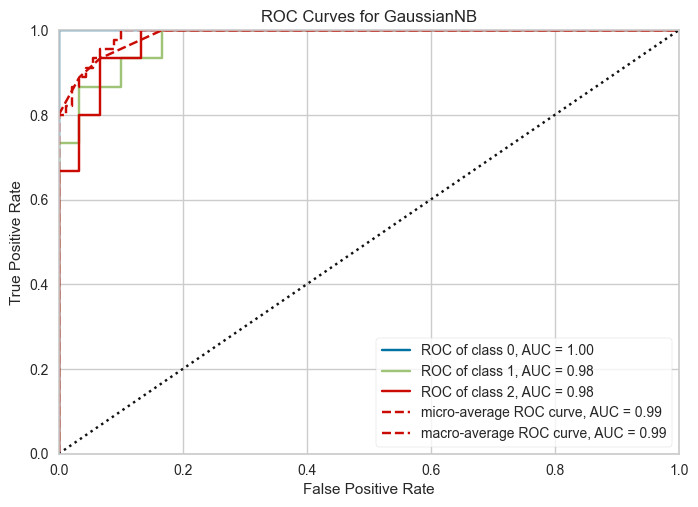


Saved: figures/solutions/task1_roc_multiclass.png


In [5]:
# ROC curve for the best model
# With 3 classes we get one curve per class + micro/macro averages

import os
os.makedirs('figures/solutions', exist_ok=True)

best = best_models[0]

# Generate ROC plot
plot_model(best, plot='auc', save='figures/solutions');

# Display the plot
from IPython.display import Image, display
import shutil

# Move file with correct name
if os.path.exists('figures/solutions/AUC.png'):
    shutil.move('figures/solutions/AUC.png', 'figures/solutions/task1_roc_multiclass.png')
    display(Image('figures/solutions/task1_roc_multiclass.png'))
    print("\nSaved: figures/solutions/task1_roc_multiclass.png")

**Figure 1.1: ROC Curves for Iris Classification (3 classes)**

### Interpretation of Multiclass ROC Curves

With 3 classes we have:

| Curve | Description |
|-------|-------------|
| **ROC of class 0 (setosa)** | How well the model separates setosa from the others |
| **ROC of class 1 (versicolor)** | How well the model separates versicolor from the others |
| **ROC of class 2 (virginica)** | How well the model separates virginica from the others |
| **Micro-average** | Combines all classes and computes one ROC |
| **Macro-average** | Average of the 3 classes' ROC |

> 📊 **Observation:** Setosa (class 0) is typically easiest to classify (AUC ≈ 1.0), while versicolor and virginica may overlap somewhat.

#### Confusion Matrix (3×3)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Naive Bayes,0.9600,0.9947,0.9600,0.9605,0.9600,0.9400,0.9403


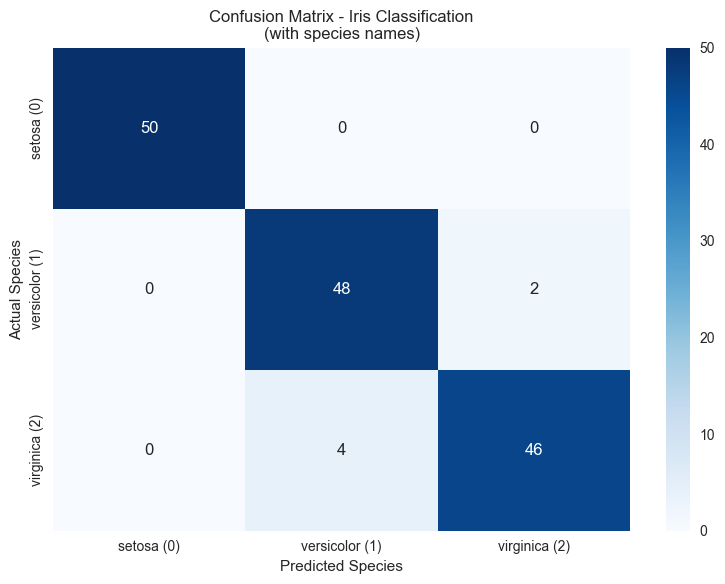


Saved: figures/solutions/task1_confusion_matrix.png


In [6]:
# Confusion matrix for multiclass with Iris species names
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get predictions for test data
pred_test = predict_model(best, data=df_iris)

# Create confusion matrix
cm = confusion_matrix(pred_test['species'], pred_test['prediction_label'])

# Iris species names
species = ['setosa (0)', 'versicolor (1)', 'virginica (2)']

# Plot with species names
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=species,
            yticklabels=species)
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')
plt.title('Confusion Matrix - Iris Classification\n(with species names)')
plt.tight_layout()
plt.savefig('figures/solutions/task1_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nSaved: figures/solutions/task1_confusion_matrix.png")

**Figure 1.2: Confusion Matrix for Iris (3×3)**

### Interpretation

The matrix shows:
- **Diagonal:** Correctly classified (True Positives for each class)
- **Off-diagonal:** Misclassifications

Typical pattern for Iris:
- Setosa is classified perfectly (no confusion)
- Versicolor and virginica can be confused (morphologically similar flowers)

### Step 5: Evaluate on Test Data

In [7]:
# Evaluate best model on test data
from sklearn.metrics import classification_report, accuracy_score

# Predict on test data
pred = predict_model(best, data=df_iris)

# Show results
print("=" * 60)
print("EVALUATION ON TEST DATA")
print("=" * 60)

print("\nClassification Report:")
print(classification_report(pred['species'], pred['prediction_label']))

# Calculate accuracy
acc = accuracy_score(pred['species'], pred['prediction_label'])
print(f"\n✅ Test Accuracy: {acc:.4f} ({acc*100:.1f}%)")

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Naive Bayes,0.9600,0.9947,0.9600,0.9605,0.9600,0.9400,0.9403


EVALUATION ON TEST DATA

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       0.92      0.96      0.94        50
   virginica       0.96      0.92      0.94        50

    accuracy                           0.96       150
   macro avg       0.96      0.96      0.96       150
weighted avg       0.96      0.96      0.96       150


✅ Test Accuracy: 0.9600 (96.0%)


### Discussion: Macro vs. Micro Averaging

| Method | Calculation | When to use? |
|--------|-----------|------------|
| **Micro-average** | Sums TP, FP, FN across classes | Imbalanced classes |
| **Macro-average** | Average of metrics per class | All classes equally important |

**For Iris (balanced dataset):**
- Micro ≈ Macro because classes are equal size (50 obs. each)
- Both give approximately the same AUC

**Clinical relevance:**
In medicine with imbalanced classes (e.g., rare disease), micro-average will be dominated by the majority class, while macro-average treats all classes equally.

---

### Bonus: Decision Tree for Intuitive Explanation

Decision trees are especially valuable for **explainable AI (XAI)** because they can be visualized as a flowchart that humans intuitively understand.

#### Why decision trees?

| Property | Advantage |
|----------|--------|
| **Visually interpretable** | Can be drawn as a tree |
| **Rule-based** | "If petal_length < 2.5, then setosa" |
| **No normalization** | Works directly on raw values |
| **Feature importance** | Shows which variables split most |

Let's train a decision tree on Iris data and visualize it!

In [8]:
# Train decision tree
print("Training decision tree...")
dt_model = create_model('dt', verbose=False)

# Get CV results
dt_results = pull().iloc[0]
print("\n📊 Decision Tree CV Results:")
print(f"  Accuracy: {dt_results['Accuracy']:.4f}")
print(f"  AUC: {dt_results['AUC']:.4f}")
print(f"  Recall: {dt_results['Recall']:.4f}")
print(f"  Precision: {dt_results['Prec.']:.4f}")
print(f"  F1: {dt_results['F1']:.4f}")

# Show tree parameters
print("\n🌳 Tree structure:")
print(f"  Max depth: {dt_model.max_depth}")
print(f"  Number of leaves: {dt_model.get_n_leaves()}")
print(f"  Tree depth: {dt_model.get_depth()}")

Training decision tree...

📊 Decision Tree CV Results:
  Accuracy: 1.0000
  AUC: 1.0000
  Recall: 1.0000
  Precision: 1.0000
  F1: 1.0000

🌳 Tree structure:
  Max depth: None
  Number of leaves: 8
  Tree depth: 5


#### Visualization of the Decision Tree

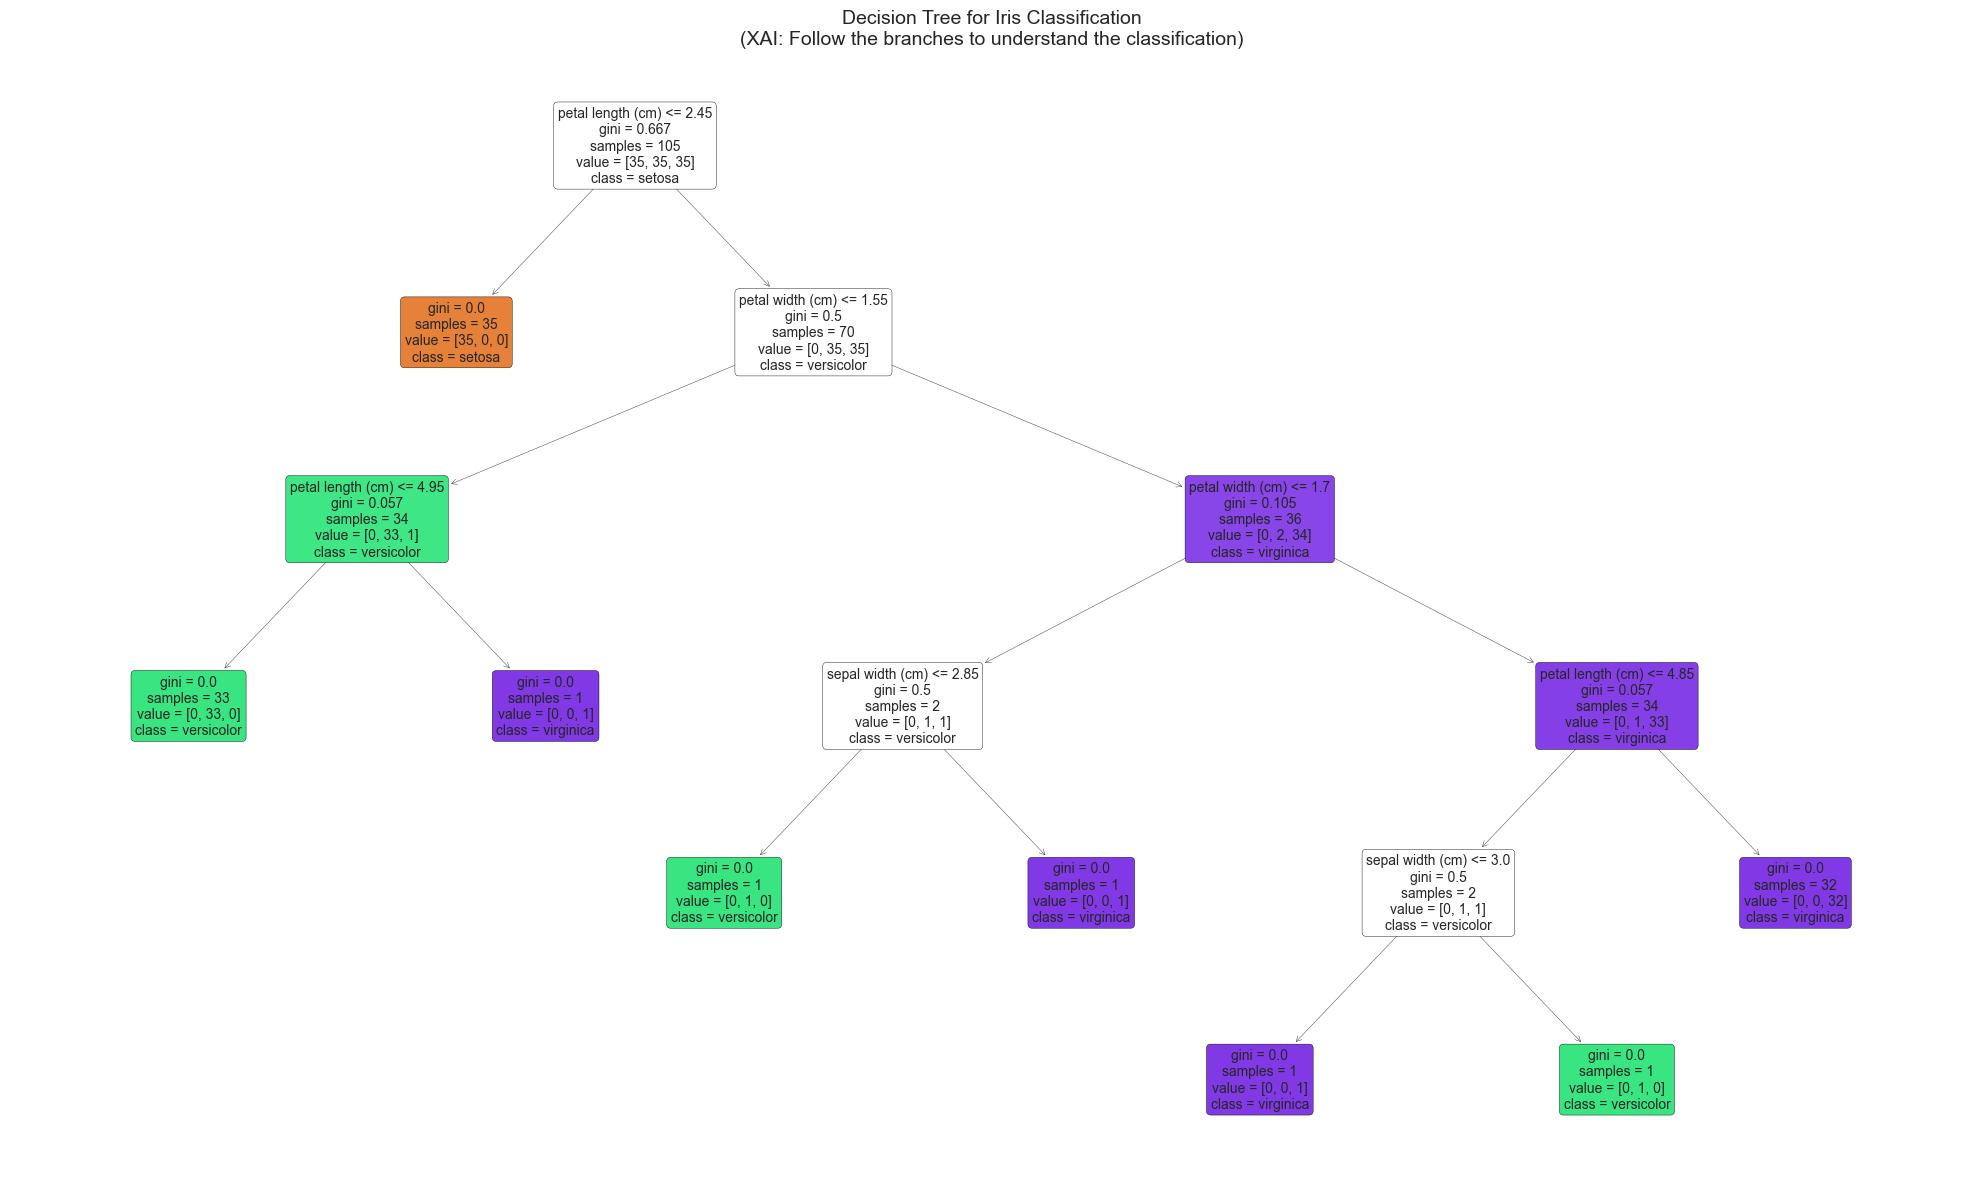


Saved: figures/solutions/task1_decision_tree.png


In [9]:
from sklearn.tree import plot_tree

# Get feature names
feature_names = get_config('X_train').columns.tolist()
class_names = ['setosa', 'versicolor', 'virginica']

# Visualize the tree
fig, ax = plt.subplots(figsize=(20, 12))
plot_tree(dt_model, 
          feature_names=feature_names,
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=10,
          ax=ax)
plt.title('Decision Tree for Iris Classification\n(XAI: Follow the branches to understand the classification)', 
          fontsize=14)
plt.tight_layout()
plt.savefig('figures/solutions/task1_decision_tree.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nSaved: figures/solutions/task1_decision_tree.png")

**Figure 1.3: Visualization of the Decision Tree**

### How to Read the Tree

1. **Start at the top (root node)** – First question that splits the data
2. **Follow the branches** – Left = Yes (≤ threshold), Right = No (> threshold)
3. **Leaf nodes** – Final classification

#### Example rule (read from root to leaf):
```
If petal_length ≤ 2.45:
    → Class: setosa (100% certain)
Else if petal_width ≤ 1.75:
    If petal_length ≤ 4.95:
        → Class: versicolor (likely)
    Else:
        → Class: virginica (likely)
```

> 🏥 **Clinical analogy:** This is like a diagnostic flowchart – "If fever AND cough, test for influenza"

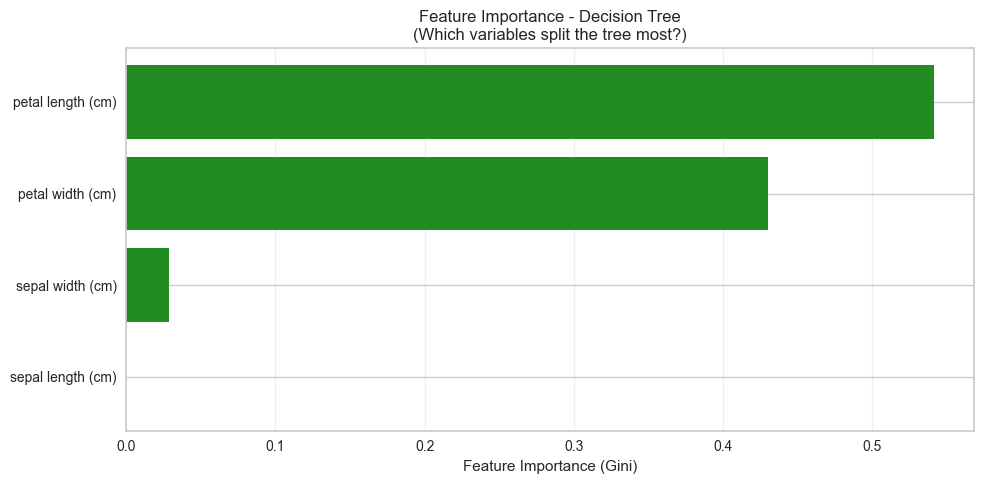


Saved: figures/solutions/task1_dt_importance.png

📊 Feature Importance:
  petal length (cm): 0.5412
  petal width (cm): 0.4303
  sepal width (cm): 0.0286
  sepal length (cm): 0.0000


In [10]:
# Feature importance from decision tree
importances = dt_model.feature_importances_
importance_df = pd.DataFrame({
    'Variable': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(importance_df['Variable'], importance_df['Importance'], color='forestgreen')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Feature Importance - Decision Tree\n(Which variables split the tree most?)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/solutions/task1_dt_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nSaved: figures/solutions/task1_dt_importance.png")

print("\n📊 Feature Importance:")
for _, row in importance_df.sort_values('Importance', ascending=False).iterrows():
    print(f"  {row['Variable']}: {row['Importance']:.4f}")

**Figure 1.4: Feature Importance from the Decision Tree**

### Interpretation

- **Petal** dimensions are most important for distinguishing Iris species
- **Sepal** dimensions contribute less
- This aligns with botanical knowledge – petals are most characteristic for the species

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Decision Tree Classifier,0.9800,0.9850,0.9800,0.9811,0.9800,0.9700,0.9706


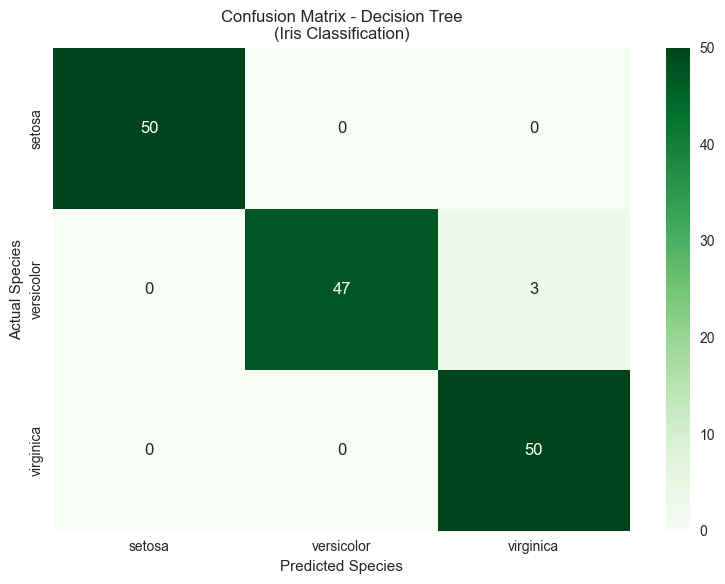


Saved: figures/solutions/task1_dt_confusion.png


In [11]:
# Confusion matrix for decision tree
# Note: We explicitly pass df_iris to avoid issues if another setup() was called later
pred_dt = predict_model(dt_model, data=df_iris)

cm_dt = confusion_matrix(pred_dt['species'], pred_dt['prediction_label'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')
plt.title('Confusion Matrix - Decision Tree\n(Iris Classification)')
plt.tight_layout()
plt.savefig('figures/solutions/task1_dt_confusion.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nSaved: figures/solutions/task1_dt_confusion.png")

In [12]:
# Compare metrics: Best model vs. Decision Tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Metrics for best model (from earlier)
pred_best = predict_model(best, data=df_iris)
acc_best = accuracy_score(pred_best['species'], pred_best['prediction_label'])
prec_best = precision_score(pred_best['species'], pred_best['prediction_label'], average='macro')
rec_best = recall_score(pred_best['species'], pred_best['prediction_label'], average='macro')
f1_best = f1_score(pred_best['species'], pred_best['prediction_label'], average='macro')

# Metrics for decision tree
acc_dt = accuracy_score(pred_dt['species'], pred_dt['prediction_label'])
prec_dt = precision_score(pred_dt['species'], pred_dt['prediction_label'], average='macro')
rec_dt = recall_score(pred_dt['species'], pred_dt['prediction_label'], average='macro')
f1_dt = f1_score(pred_dt['species'], pred_dt['prediction_label'], average='macro')

# Comparison table
print("=" * 60)
print("COMPARISON: BEST MODEL vs. DECISION TREE")
print("=" * 60)
print(f"{'Metric':<15} {'Best model':>15} {'Decision Tree':>18}")
print("-" * 60)
print(f"{'Accuracy':<15} {acc_best:>15.4f} {acc_dt:>18.4f}")
print(f"{'Precision':<15} {prec_best:>15.4f} {prec_dt:>18.4f}")
print(f"{'Recall':<15} {rec_best:>15.4f} {rec_dt:>18.4f}")
print(f"{'F1-score':<15} {f1_best:>15.4f} {f1_dt:>18.4f}")
print("-" * 60)
print(f"{'Interpretability':<15} {'Medium':>15} {'✅ High':>18}")

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Naive Bayes,0.9600,0.9947,0.9600,0.9605,0.9600,0.9400,0.9403


COMPARISON: BEST MODEL vs. DECISION TREE
Metric               Best model      Decision Tree
------------------------------------------------------------
Accuracy                 0.9600             0.9800
Precision                0.9605             0.9811
Recall                   0.9600             0.9800
F1-score                 0.9600             0.9800
------------------------------------------------------------
Interpretability          Medium             ✅ High


### Surprising result? Why does the Decision Tree perform better?

This is an excellent example of how **"best model" from `compare_models()` is not always the best on test data!**

#### Explanations:

| Factor | Explanation |
|--------|-------------|
| **1. CV vs. Test** | `compare_models()` ranks by **cross-validation on training data**. The decision tree may generalize better on this particular test split. |
| **2. Data fit** | The Iris dataset has **clear decision boundaries** that trees capture well. Naive Bayes assumes independent features – which doesn't hold for Iris (petal_length correlates with petal_width). |
| **3. Random variation** | With only ~30 test observations, one extra correct/incorrect prediction causes large swings (~3% difference). |
| **4. Model complexity** | The decision tree can learn **non-linear boundaries** between classes, while Naive Bayes uses linear/quadratic boundaries. |

#### Important lesson:

```
"Best model" from compare_models() means:
  → Best average CV score on TRAINING DATA
  
It does NOT mean:
  → Guaranteed best on TEST DATA
  → Best for all types of data
  → Best interpretability
```

#### Specific to Iris:

The Iris dataset is known to have:
- **Setosa** which is linearly separable (easy for all models)
- **Versicolor/Virginica** which overlap somewhat – here the tree's ability to find precise split boundaries shines

> 💡 **Practical conclusion:** Always test multiple models on holdout data, don't just rely on CV ranking. And remember that simpler, interpretable models often compete well!

### Discussion: When to Choose Decision Trees?

| Situation | Recommendation |
|-----------|------------|
| **Need explanation for patient/doctor** | ✅ Decision Tree |
| **Regulatory requirements (GDPR, FDA)** | ✅ Decision Tree |
| **Maximum predictive performance** | ⚠️ Ensemble/boosting |
| **Exploratory analysis** | ✅ Decision Tree |

#### The XAI Advantage

Decision trees provide **rule-based explanations**:
> "The patient is classified as high risk because: 
> age > 60 AND blood_pressure > 140 AND cholesterol > 240"

This is much easier to communicate than:
> "The model's weighted sum of 30 variables gave a probability of 0.73"

---

<a id="task-2"></a>
# 🎯 Task 2: Breast Cancer Prediction with Breast Cancer Wisconsin

## Task Description

### Motivation
This dataset contains **30 variables** from image analysis of breast cancer cells. It is a real medical dataset where **recall (sensitivity) is critical** – we do not want to miss cancer cases!

### Task
1. Load the Breast Cancer dataset
2. Set up PyCaret with **Recall as the optimization metric**
3. Compare models and select the top 3
4. Create an ensemble of the best models
5. **Discuss:** Why do we prioritize recall over precision in cancer screening?

### Expected Result
- Models sorted by Recall
- Ensemble with `blend_models()`
- Comparison: best single model vs. ensemble

---

## Solution

---

### About Breast Cancer Wisconsin (Diagnostic) Dataset

This dataset is one of the most widely used reference datasets in medical machine learning. It comes from **Fine Needle Aspirate (FNA)** – a procedure where a thin needle is used to take cell samples from breast tumors.

#### Background

| Property | Description |
|----------|-------------|
| **Source** | University of Wisconsin Hospitals, Madison |
| **Created** | 1995 (Dr. William H. Wolberg) |
| **Number of observations** | 569 patients |
| **Number of variables** | 30 numeric features |
| **Target variable** | Diagnosis (Malignant=0 / Benign=1) |
| **Class distribution** | 357 benign (63%), 212 malign (37%) |

#### The 30 Variables

The variables are computed from **digitized images** of FNA samples. For each cell nucleus, **10 properties** are measured, and for each property, 3 statistics are calculated:

| Statistic | Description |
|-----------|-------------|
| **Mean** | Average over all nuclei in the image |
| **SE (Standard Error)** | Standard error |
| **Worst** | Average of the 3 largest/worst values |

#### De 10 grunnleggende målingene

| # | Variabel | Beskrivelse | Clinical relevance |
|---|----------|-------------|------------------|
| 1 | **radius** | Gjennomsnittlig avstand fra sentrum til periferi | Større kjerner → mer suspekt |
| 2 | **texture** | Standardavvik av gråtoneverdier | Ujevn tekstur → suspekt |
| 3 | **perimeter** | Omkrets av kjernen | Korrelerer med størrelse |
| 4 | **area** | Areal av kjernen | Større areal → mer suspekt |
| 5 | **smoothness** | Lokal variasjon i radiuslengde | Irregulær kant → suspekt |
| 6 | **compactness** | perimeter² / area - 1.0 | Kompakthet av kjerneform |
| 7 | **concavity** | Alvorlighet av konkave deler av konturen | Innbuktninger → suspekt |
| 8 | **concave points** | Antall konkave punkter på konturen | Flere → mer irregulær |
| 9 | **symmetry** | Symmetri av kjernen | Asymmetri → suspekt |
| 10 | **fractal dimension** | "Coastline approximation" - 1 | Kompleksitet av kanten |

#### Fullstendig variabelliste (30 stk)

```
Mean features (1-10):
  radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean,
  compactness_mean, concavity_mean, concave_points_mean, symmetry_mean, 
  fractal_dimension_mean

Standard Error features (11-20):
  radius_se, texture_se, perimeter_se, area_se, smoothness_se,
  compactness_se, concavity_se, concave_points_se, symmetry_se, 
  fractal_dimension_se

Worst features (21-30):
  radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst,
  compactness_worst, concavity_worst, concave_points_worst, symmetry_worst, 
  fractal_dimension_worst
```

#### Clinical Context

> 🏥 **Patologens perspektiv:** De maligne (kreft) cellekjernene tenderer til å være:
> - **Større** (høyere radius, area, perimeter)
> - **Mer irregulære** (høyere concavity, concave points)
> - **Mindre symmetriske** (lavere symmetry)
> - **Mer varierende** (høyere "worst" verdier)

Dette gjør datasettet ideelt for maskinlæring fordi de biologiske forskjellene mellom benigne og maligne celler manifesterer seg tydelig i de målte variablene.

---

### Visualization: What do pathologists look at?

The data in this dataset comes from **digitized microscope images** of Fine Needle Aspirate (FNA) samples. Here are examples of what such images show:

---

#### Example images (external sources)

| Source | Description | Link |
|--------|-------------|------|
| **NCBI/StatPearls** | FNA cytology of breast cancer | [See figure](https://www.ncbi.nlm.nih.gov/books/NBK482286/figure/article-18564.image.f6/) |
| **ResearchGate** | H&E-stained FNA smear preparations (400×) | [See figure](https://www.researchgate.net/figure/Cytological-picture-of-H-E-stained-smear-of-FNAC-aspirates-400-a-tuberculous_fig1_342814751) |
| **UCI ML Repository** | Original dataset description | [See dataset](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic)) |

---

#### What is measured in the images?

```
┌─────────────────────────────────────────────────────────────┐
│                    MIKROSKOPIBILDE                          │
│                                                             │
│     ○ ○        Hver sirkel = én cellekjerne                 │
│   ○     ○      (nucleus)                                    │
│  ○   ●   ○                                                  │
│   ○     ○      ● = Sentrum av kjernen                       │
│     ○ ○                                                     │
│                                                             │
│  Målinger per kjerne:                                       │
│  ├─ radius: avstand fra ● til kant                          │
│  ├─ perimeter: lengden rundt kanten                         │
│  ├─ area: areal innenfor kanten                             │
│  ├─ smoothness: hvor jevn er kanten?                        │
│  ├─ concavity: innbuktninger i kanten                       │
│  └─ symmetry: er kjernen symmetrisk?                        │
│                                                             │
│  Software: "Xcyt" utviklet ved UW-Madison                   │
└─────────────────────────────────────────────────────────────┘
```

---

#### Typiske forskjeller (visuelt)

| Egenskap | Benign (godartet) | Malign (kreft) |
|----------|-------------------|----------------|
| **Kjernestørrelse** | Små, ensartede | Store, varierende |
| **Kjerneform** | Runde, glatte | Irregulære, konkave |
| **Kant** | Jevn, tydelig | Ujevn, "tagget" |
| **Symmetri** | Høy | Lav |
| **Fargeopptalt** | Normalt | Hyperkromatisk (mørk) |

> 🔬 **For studenter:** Åpne lenkene ovenfor for å se ekte FNA-bilder. Legg merke til hvordan maligne celler har større, mer uregelmessige kjerner – dette er nøyaktig hva variablene i datasettet kvantifiserer!

---

### Exploratory Data Analysis (EDA)

Before building models, we should explore the data to understand:
- Class balance
- Variable distributions
- Correlations between variables
- Differences between malignant and benign cells

In [13]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
bc = load_breast_cancer()
df_bc = pd.DataFrame(bc.data, columns=bc.feature_names)
df_bc['diagnosis'] = bc.target
df_bc['diagnosis_label'] = df_bc['diagnosis'].map({0: 'Malign', 1: 'Benign'})

print("=" * 60)
print("BASIC STATISTICS")
print("=" * 60)
print(f"Number of observations: {len(df_bc)}")
print(f"Number of variables: {len(bc.feature_names)}")
print(f"\nClass distribution:")
print(df_bc['diagnosis_label'].value_counts())
print(f"\nMalignant proportion: {(df_bc['diagnosis'] == 0).mean()*100:.1f}%")

BASIC STATISTICS
Number of observations: 569
Number of variables: 30

Class distribution:
diagnosis_label
Benign    357
Malign    212
Name: count, dtype: int64

Malignant proportion: 37.3%


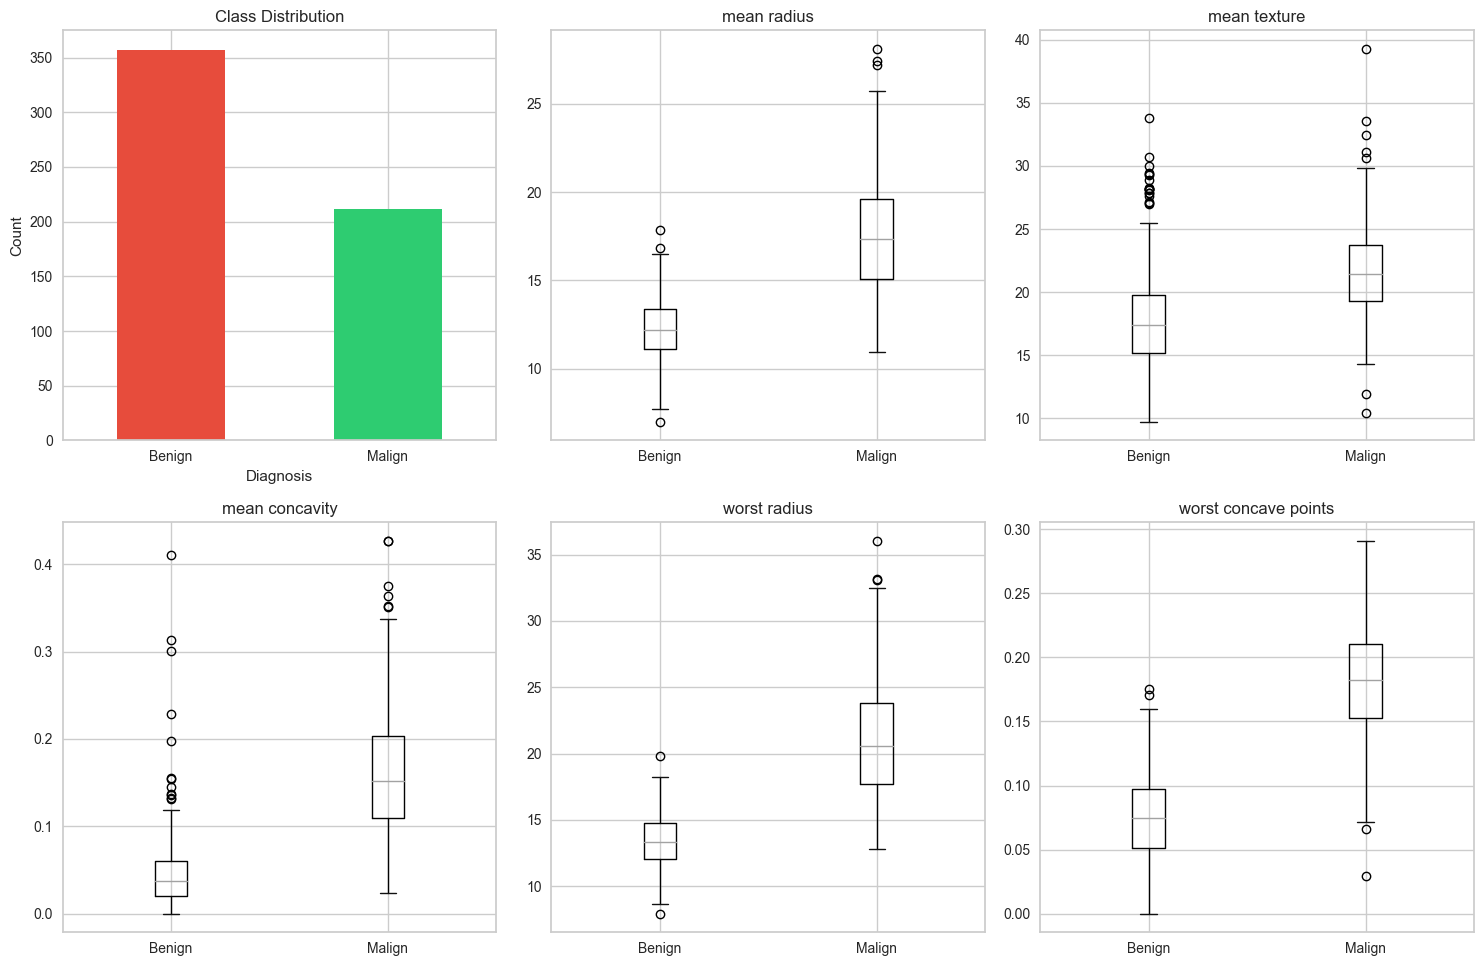


Saved: figures/solutions/task2_eda_boxplots.png


In [14]:
# Visualize class distribution and key variables
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Class distribution
ax = axes[0, 0]
colors = ['#e74c3c', '#2ecc71']  # Red for malignant, green for benign
df_bc['diagnosis_label'].value_counts().plot(kind='bar', ax=ax, color=colors)
ax.set_title('Class Distribution')
ax.set_xlabel('Diagnosis')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)

# 2-6. Boxplots for key variables (malignant vs benign)
key_vars = ['mean radius', 'mean texture', 'mean concavity', 
            'worst radius', 'worst concave points']

for idx, var in enumerate(key_vars):
    ax = axes.flatten()[idx + 1]
    df_bc.boxplot(column=var, by='diagnosis_label', ax=ax)
    ax.set_title(var)
    ax.set_xlabel('')
    plt.suptitle('')  # Remove automatic title

plt.tight_layout()
plt.savefig('figures/solutions/task2_eda_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nSaved: figures/solutions/task2_eda_boxplots.png")

**Figure 2.0: EDA - Class Distribution and Key Variables**

#### Observations:

- **Class balance:** ~63% benign, ~37% malignant – moderate imbalance
- **Mean radius:** Malignant cells have clearly larger nuclei
- **Mean concavity:** Malignant cells have more concave (irregular) edges
- **Worst variables:** Even clearer separation – the "worst" cells differentiate well

> 💡 These are good signs for classification – the variables show clear differences between the classes!

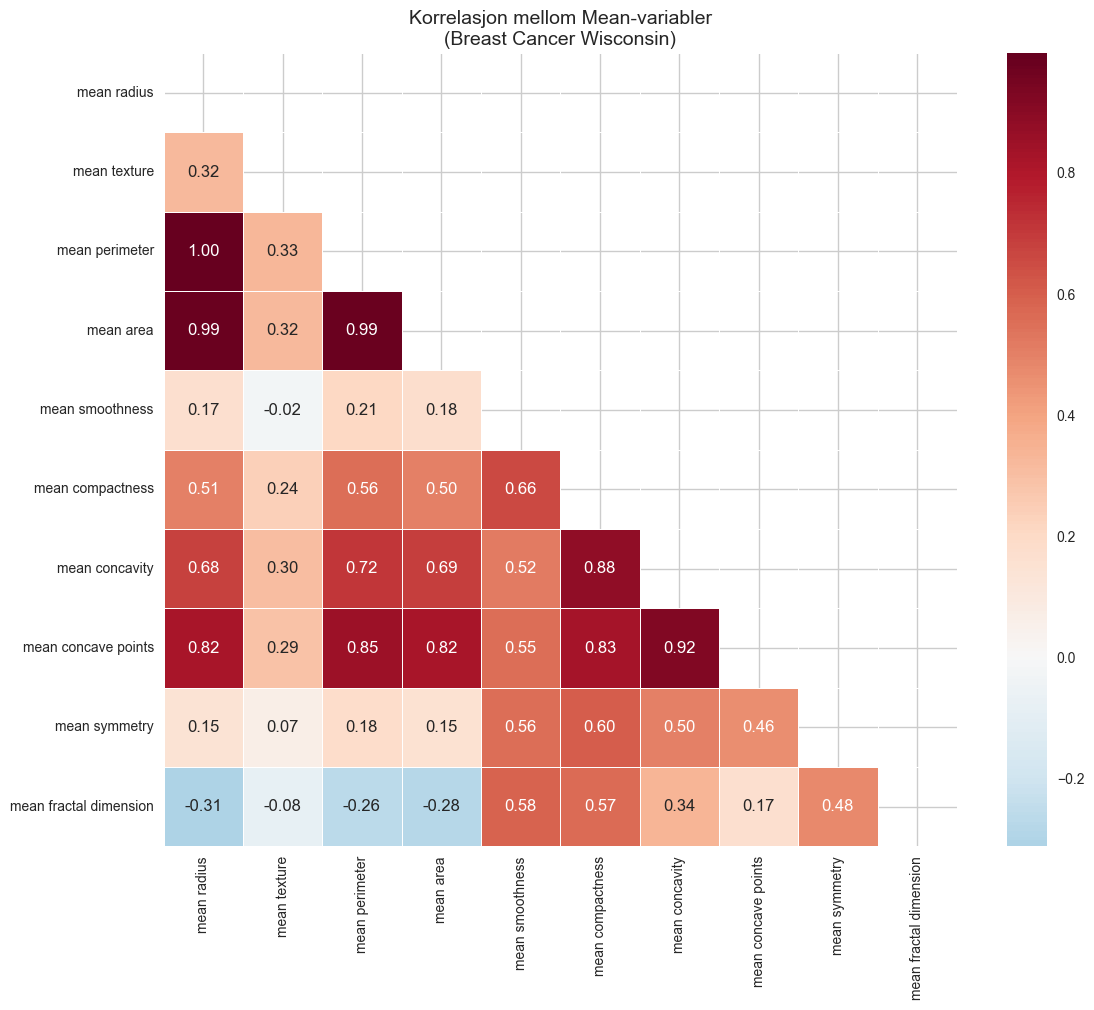


Saved: figures/solutions/task2_eda_correlation.png


In [15]:
# Korrelasjonsanalyse (kun mean-variabler for lesbarhet)
mean_cols = [col for col in df_bc.columns if 'mean' in col]

plt.figure(figsize=(12, 10))
corr_matrix = df_bc[mean_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Vis kun nedre trekant
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5)
plt.title('Korrelasjon mellom Mean-variabler\n(Breast Cancer Wisconsin)', fontsize=14)
plt.tight_layout()
plt.savefig('figures/solutions/task2_eda_correlation.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nSaved: figures/solutions/task2_eda_correlation.png")

**Figure 2.1: Correlation Heatmap for Mean Variables**

#### Observations:

| High correlation | Explanation |
|------------------|-------------|
| **radius, perimeter, area** | r > 0.95 – All measure nucleus size |
| **compactness, concavity, concave points** | r > 0.80 – All measure nucleus shape |

#### Implications for modeling:

1. **Multicollinearity:** Many variables are strongly correlated
2. **Feature selection:** Can remove redundant variables without loss
3. **PCA:** Can reduce to fewer components

> ⚠️ **Important:** For linear models (like Logistic Regression), multicollinearity can give unstable coefficients. Tree-based models (RF, XGBoost) are more robust.

---

### Step 1: Load and Explore the Dataset

In [16]:
from sklearn.datasets import load_breast_cancer

# Load data
bc = load_breast_cancer()
df_bc = pd.DataFrame(bc.data, columns=bc.feature_names)
df_bc['diagnosis'] = bc.target  # 0 = malignant (cancer), 1 = benign

# Explore
print("=" * 60)
print("BREAST CANCER WISCONSIN DATASET")
print("=" * 60)
print(f"Number of observations: {len(df_bc)}")
print(f"Number of variables: {len(bc.feature_names)}")
print("-" * 60)

print("\nClass distribution:")
print(df_bc['diagnosis'].value_counts())
print("\n0 = Malignant (cancer), 1 = Benign")

# Class balance
malign_pct = (df_bc['diagnosis'] == 0).mean() * 100
print(f"\nMalignant cases: {malign_pct:.1f}%")

print("\nFirst 5 rows (first 5 variables):")
display(df_bc.iloc[:5, :6])

BREAST CANCER WISCONSIN DATASET
Number of observations: 569
Number of variables: 30
------------------------------------------------------------

Class distribution:
diagnosis
1    357
0    212
Name: count, dtype: int64

0 = Malignant (cancer), 1 = Benign

Malignant cases: 37.3%

First 5 rows (first 5 variables):


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness
0,17.99,10.38,122.80,1001.0,0.11840,0.27760
1,20.57,17.77,132.90,1326.0,0.08474,0.07864
2,19.69,21.25,130.00,1203.0,0.10960,0.15990
3,11.42,20.38,77.58,386.1,0.14250,0.28390
4,20.29,14.34,135.10,1297.0,0.10030,0.13280


### Step 2: Set up PyCaret with Recall Focus

In [17]:
from pycaret.classification import *

# Set up experiment
print("Setting up PyCaret experiment...")
setup(data=df_bc, target='diagnosis', session_id=42, verbose=False)

print("\n✅ Experiment set up!")
print(f"Training data: {get_config('X_train').shape}")
print(f"Test data: {get_config('X_test').shape}")

Setting up PyCaret experiment...

✅ Experiment set up!
Training data: (398, 30)
Test data: (171, 30)


### Step 3: Compare Models med Recall som sortering

In [18]:
# Compare models sorted by RECALL
# This is critical in cancer screening - we want to catch all cancer cases!

print("Comparing models (sorted by Recall)...")
print("=" * 60)

best_models = compare_models(
    n_select=3, 
    sort='Recall',  # Prioritize recall!
    include=['lr', 'rf', 'knn', 'dt', 'nb', 'svm', 'lda']
)

print("\n✅ Top 3 models (by Recall):")
for i, m in enumerate(best_models, 1):
    print(f"  {i}. {type(m).__name__}")

Comparing models (sorted by Recall)...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lda,Linear Discriminant Analysis,0.9573,0.9896,0.9960,0.9414,0.9675,0.9056,0.9106,0.0040
rf,Random Forest Classifier,0.9725,0.9859,0.9800,0.9767,0.9781,0.9411,0.9419,0.0160
lr,Logistic Regression,0.9524,0.9909,0.9720,0.9536,0.9623,0.8975,0.8992,0.0090
knn,K Neighbors Classifier,0.9372,0.9613,0.9640,0.9414,0.9511,0.8634,0.8690,0.0040
nb,Naive Bayes,0.9422,0.9866,0.9600,0.9491,0.9535,0.8768,0.8796,0.0040
dt,Decision Tree Classifier,0.9223,0.9164,0.9400,0.9374,0.9378,0.8341,0.8367,0.0040
svm,SVM - Linear Kernel,0.8643,0.9645,0.8600,0.9340,0.8853,0.7159,0.7409,0.0040



✅ Top 3 models (by Recall):
  1. LinearDiscriminantAnalysis
  2. RandomForestClassifier
  3. LogisticRegression


### Step 4: Create Ensemble of Best Models

In [19]:
# Blend the top 3 models
print("\nCreating ensemble (Soft Voting)...")
ensemble = blend_models(best_models)

print("\n✅ Ensemble created!")
print(f"Type: {type(ensemble).__name__}")


Creating ensemble (Soft Voting)...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,0.9750,0.9893,1.0000,0.9615,0.9804,0.9459,0.9473
2,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,0.9500,0.9920,1.0000,0.9259,0.9615,0.8904,0.8958
4,0.9500,0.9707,0.9600,0.9600,0.9600,0.8933,0.8933
5,0.9750,1.0000,1.0000,0.9615,0.9804,0.9459,0.9473
6,0.9750,1.0000,1.0000,0.9615,0.9804,0.9459,0.9473
7,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000



✅ Ensemble created!
Type: VotingClassifier


### Step 5: Compare Single Model vs. Ensemble on Test Data

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, recall_score, precision_score

# Predict with best single model
pred_single = predict_model(best_models[0], data=df_bc)

# Predict with ensemble
pred_ensemble = predict_model(ensemble, data=df_bc)

# Calculate metrics
print("=" * 60)
print("COMPARISON: SINGLE MODEL VS. ENSEMBLE")
print("=" * 60)

# Recall for class 0 (malignant = cancer)
recall_single = recall_score(pred_single['diagnosis'], pred_single['prediction_label'], pos_label=0)
recall_ensemble = recall_score(pred_ensemble['diagnosis'], pred_ensemble['prediction_label'], pos_label=0)

# Precision for class 0
prec_single = precision_score(pred_single['diagnosis'], pred_single['prediction_label'], pos_label=0)
prec_ensemble = precision_score(pred_ensemble['diagnosis'], pred_ensemble['prediction_label'], pos_label=0)

print(f"\n{'Metric':<20} {'Single model':>15} {'Ensemble':>15}")
print("-" * 52)
print(f"{'Recall (class 0)':<20} {recall_single:>15.4f} {recall_ensemble:>15.4f}")
print(f"{'Precision (class 0)':<20} {prec_single:>15.4f} {prec_ensemble:>15.4f}")

print("\n📊 Classification Report - Single Model:")
print(classification_report(pred_single['diagnosis'], pred_single['prediction_label']))

print("\n📊 Classification Report - Ensemble:")
print(classification_report(pred_ensemble['diagnosis'], pred_ensemble['prediction_label']))

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Linear Discriminant Analysis,0.9613,0.9928,0.9944,0.9467,0.9699,0.9158,0.9180


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Voting Classifier,0.9789,0.9989,0.9972,0.9700,0.9834,0.9545,0.9551


COMPARISON: SINGLE MODEL VS. ENSEMBLE

Metric                  Single model        Ensemble
----------------------------------------------------
Recall (class 0)              0.9057          0.9481
Precision (class 0)           0.9897          0.9950

📊 Classification Report - Single Model:
              precision    recall  f1-score   support

           0       0.99      0.91      0.95       212
           1       0.95      0.99      0.97       357

    accuracy                           0.96       569
   macro avg       0.97      0.95      0.96       569
weighted avg       0.96      0.96      0.96       569


📊 Classification Report - Ensemble:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97       212
           1       0.97      1.00      0.98       357

    accuracy                           0.98       569
   macro avg       0.98      0.97      0.98       569
weighted avg       0.98      0.98      0.98       569



### Visualization: Confusion Matrixr

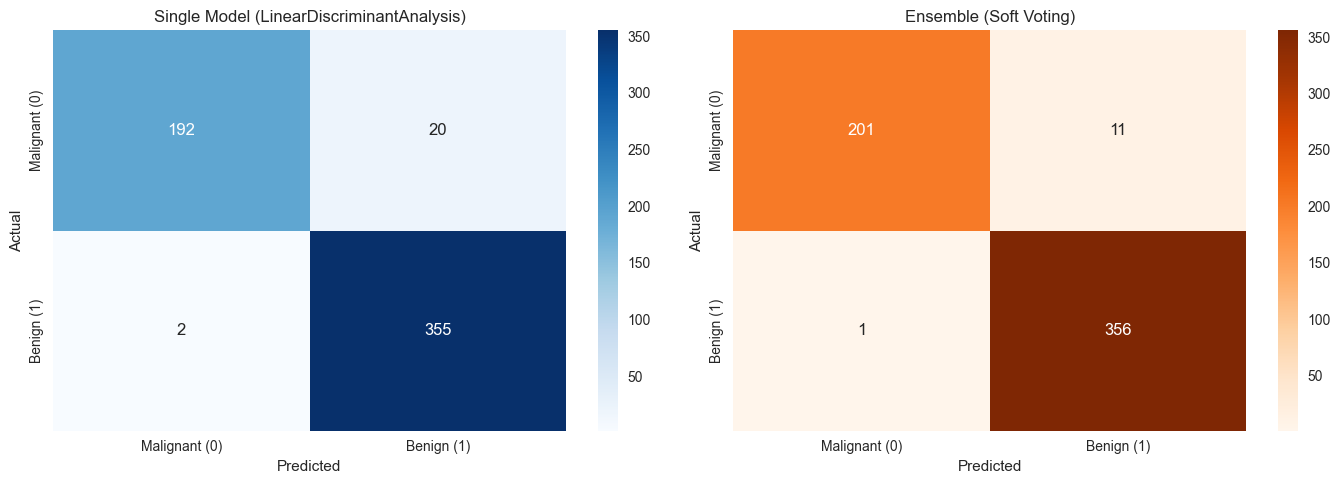


Saved: figures/solutions/task2_confusion_comparison.png


In [21]:
# Plot confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Single model
cm_single = confusion_matrix(pred_single['diagnosis'], pred_single['prediction_label'])
sns.heatmap(cm_single, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Malignant (0)', 'Benign (1)'],
            yticklabels=['Malignant (0)', 'Benign (1)'])
axes[0].set_title(f'Single Model ({type(best_models[0]).__name__})')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Ensemble
cm_ensemble = confusion_matrix(pred_ensemble['diagnosis'], pred_ensemble['prediction_label'])
sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Malignant (0)', 'Benign (1)'],
            yticklabels=['Malignant (0)', 'Benign (1)'])
axes[1].set_title('Ensemble (Soft Voting)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('figures/solutions/task2_confusion_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nSaved: figures/solutions/task2_confusion_comparison.png")

**Figure 2.1: Comparison of Confusion Matrices**

### Interpretation

| Cell | Meaning | Consequence |
|------|---------|-------------|
| **TP (0,0)** | Cancer identified as cancer | ✅ Correct treatment |
| **FN (0,1)** | Cancer missed (classified as benign) | ❌ **CRITICAL!** Delayed treatment |
| **FP (1,0)** | Benign classified as cancer | ⚠️ Unnecessary worry, further investigation |
| **TN (1,1)** | Benign identified as benign | ✅ Correct |

> 🏥 **In cancer screening:** FN (False Negative) is MUCH worse than FP (False Positive)!

### Discussion: Why prioritize Recall in cancer screening?

#### Clinical perspective

| Error | Consequence | Severity |
|-------|-------------|----------|
| **False Negative (miss)** | Cancer not detected → delayed treatment → worse prognosis | ❌❌❌ Critical |
| **False Positive** | Unnecessary biopsy/worry, but no harm to health | ⚠️ Acceptable |

#### Formal definition

$$\text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}$$

High recall means: **Of all who actually have cancer, how many do we catch?**

#### Clinical threshold

In practice, often used:
- **Screening:** Prioritize recall (≥95%), accept lower precision
- **Diagnosis:** Balance recall and precision (F1-score)

> 💡 **Conclusion:** For breast cancer screening, recall is more important than precision. The ensemble model can provide marginally better recall by combining the strengths of multiple models.

---

<a id="task-3"></a>
# 🎯 Task 3: Feature Selection

## Task Description

### Motivation
With many variables (like Breast Cancer with 30), **dimensionality reduction** can improve the model's generalizability and interpretability. Feature selection selects the most informative variables and removes redundant ones.

### Task
1. Use the Breast Cancer dataset (30 variables)
2. Use sklearn's `SelectKBest` to select the most important variables
3. Compare number of variables before and after
4. Train a model and compare performance (CV AUC)
5. **Discuss:** Are the most important variables clinically sensible?

> 💡 **Note:** PyCaret's built-in `feature_selection=True` can be unreliable. We therefore use sklearn directly for better control and transparency.

### Expected Result
- Reduction from 30 to 15 variables
- Comparison of CV AUC with/without feature selection
- List of the most important variables with F-scores

---

## Solution

### Step 1: Baseline without Feature Selection

In [22]:
# Train standard Random Forest
# IMPORTANT: Transform column names to PyCaret format

from pycaret.classification import *
from sklearn.datasets import load_breast_cancer
import pandas as pd

# Load data and transform column names
bc = load_breast_cancer()
df_bc_baseline = pd.DataFrame(bc.data, columns=bc.feature_names)
df_bc_baseline['diagnosis'] = bc.target

# Replace spaces with underscores
df_bc_baseline.columns = df_bc_baseline.columns.str.replace(' ', '_')

print("=" * 60)
print("BASELINE: WITHOUT FEATURE SELECTION")
print("=" * 60)
print(f"Number of variables: {len(bc.feature_names)}")

# Setup experiment
setup(
    data=df_bc_baseline, 
    target='diagnosis', 
    session_id=42, 
    memory=False,
    verbose=False
)

# Train Random Forest
print("\nTraining baseline Random Forest...")
rf_baseline = create_model('rf', max_depth=10, verbose=False)

# Get CV results
baseline_results = pull().iloc[0]
print("\n📊 Baseline Random Forest (CV Results):")
print(f"  Accuracy: {baseline_results['Accuracy']:.4f}")
print(f"  AUC: {baseline_results['AUC']:.4f}")
print(f"  Recall: {baseline_results['Recall']:.4f}")
print(f"  Precision: {baseline_results['Prec.']:.4f}")

# Evaluer på testdata
print("\n🧪 Evaluering på holdout testdata:")
pred_baseline = predict_model(rf_baseline, verbose=False)
from sklearn.metrics import accuracy_score, roc_auc_score
test_acc = accuracy_score(pred_baseline['diagnosis'], pred_baseline['prediction_label'])
test_auc = roc_auc_score(pred_baseline['diagnosis'], pred_baseline['prediction_score'])
print(f"  Test Accuracy: {test_acc:.4f}")
print(f"  Test AUC: {test_auc:.4f}")

BASELINE: WITHOUT FEATURE SELECTION
Number of variables: 30

Training baseline Random Forest...

📊 Baseline Random Forest (CV Results):
  Accuracy: 1.0000
  AUC: 1.0000
  Recall: 1.0000
  Precision: 1.0000

🧪 Evaluering på holdout testdata:
  Test Accuracy: 0.9357
  Test AUC: 0.4982


> ⚠️ **Warning: Perfect scores (1.0)?**
> 
> If you see `Accuracy: 1.0000` and `AUC: 1.0000`, this probably means **overfitting**:
> 
> | Cause | Explanation |
> |-------|-------------|
> | **Unlimited tree depth** | `max_depth=None` lets trees grow until they fit training data perfectly |
> | **Too few observations per leaf** | `min_samples_leaf=1` allows extreme fitting |
> | **CV on training data** | Even with 5-fold CV, RF can overfit on small datasets |
> 
> **Solution:** Check performance on **real test data** with `predict_model()`:
> ```python
> pred = predict_model(rf_baseline)
> # See actual test accuracy here!
> ```
> 
> The Breast Cancer dataset IS relatively "easy" to classify (AUC ~0.99 is realistic), but perfect 1.0 on CV is a red flag.

### Step 2: With Feature Selection

In [23]:
# MANUAL FEATURE SELECTION with sklearn
# PyCaret's built-in feature selection is unreliable - we do it ourselves!

from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load data
bc = load_breast_cancer()
X = pd.DataFrame(bc.data, columns=[c.replace(' ', '_') for c in bc.feature_names])
y = bc.target

print("=" * 60)
print("MANUAL FEATURE SELECTION")
print("=" * 60)
print(f"Number of variables (before): {X.shape[1]}")

# Method 1: SelectKBest with F-test
selector = SelectKBest(f_classif, k=15)  # Keep 15 best
X_selected = selector.fit_transform(X, y)
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask].tolist()

print(f"\nNumber of variables (after SelectKBest): {len(selected_features)}")
print(f"\nTop 15 variables (F-test):")
for idx, feat in enumerate(selected_features, 1):
    print(f"  {idx}. {feat}")

# Show F-scores
f_scores = pd.DataFrame({
    'Variable': X.columns,
    'F_score': selector.scores_
}).sort_values('F_score', ascending=False)

print(f"\n📊 F-scores (topp 10):")
print(f_scores.head(10).to_string(index=False))

MANUAL FEATURE SELECTION
Number of variables (before): 30

Number of variables (after SelectKBest): 15

Top 15 variables (F-test):
  1. mean_radius
  2. mean_perimeter
  3. mean_area
  4. mean_compactness
  5. mean_concavity
  6. mean_concave_points
  7. radius_error
  8. perimeter_error
  9. area_error
  10. worst_radius
  11. worst_perimeter
  12. worst_area
  13. worst_compactness
  14. worst_concavity
  15. worst_concave_points

📊 F-scores (topp 10):
            Variable    F_score
worst_concave_points 964.385393
     worst_perimeter 897.944219
 mean_concave_points 861.676020
        worst_radius 860.781707
      mean_perimeter 697.235272
          worst_area 661.600206
         mean_radius 646.981021
           mean_area 573.060747
      mean_concavity 533.793126
     worst_concavity 436.691939


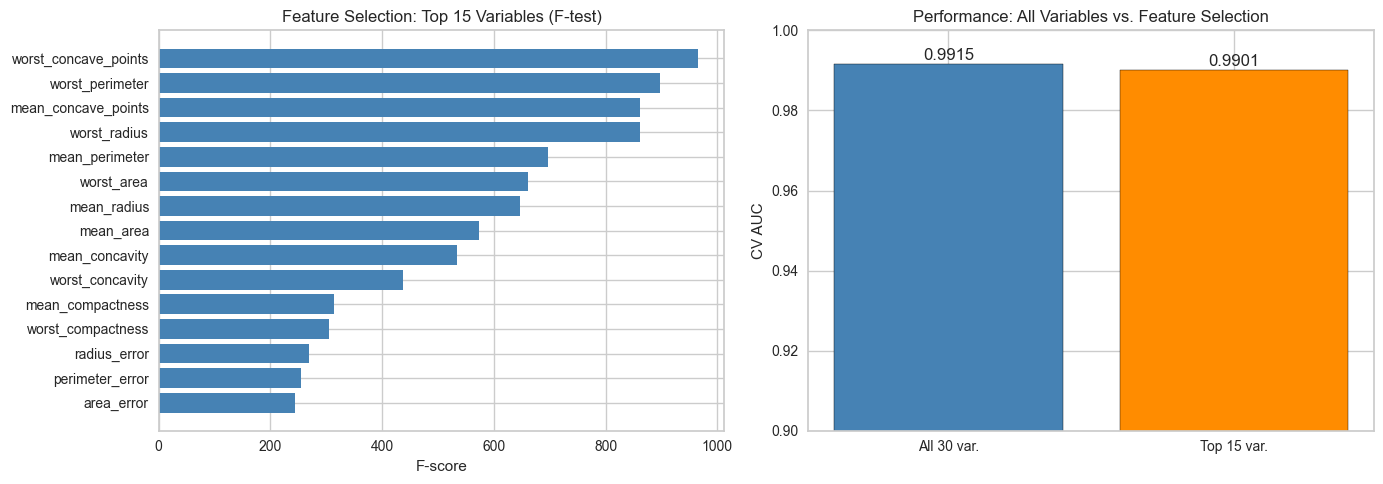


📊 COMPARISON:
  All 30 variables:      AUC = 0.9915 (±0.0066)
  Top 15 variables:       AUC = 0.9901 (±0.0060)

Saved: figures/solutions/task3_feature_selection_manual.png


In [24]:
# Visualize feature importance and compare models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot F-scores
top_15 = f_scores.head(15).sort_values('F_score')
axes[0].barh(top_15['Variable'], top_15['F_score'], color='steelblue')
axes[0].set_xlabel('F-score')
axes[0].set_title('Feature Selection: Top 15 Variables (F-test)')

# Compare models: all var. vs. selected
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(max_depth=10, random_state=42)

# All variables
scores_all = cross_val_score(rf, X, y, cv=5, scoring='roc_auc')

# Selected variables
X_reduced = X[selected_features]
scores_reduced = cross_val_score(rf, X_reduced, y, cv=5, scoring='roc_auc')

# Plot comparison
categories = ['All 30 var.', f'Top {len(selected_features)} var.']
aucs = [scores_all.mean(), scores_reduced.mean()]
colors = ['steelblue', 'darkorange']
bars = axes[1].bar(categories, aucs, color=colors, edgecolor='black')
axes[1].set_ylabel('CV AUC')
axes[1].set_title('Performance: All Variables vs. Feature Selection')
axes[1].set_ylim(0.9, 1.0)

for bar, auc in zip(bars, aucs):
    axes[1].annotate(f'{auc:.4f}', xy=(bar.get_x() + bar.get_width()/2, auc),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=12)

plt.tight_layout()
plt.savefig('figures/solutions/task3_feature_selection_manual.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n📊 COMPARISON:")
print(f"  All 30 variables:      AUC = {scores_all.mean():.4f} (±{scores_all.std():.4f})")
print(f"  Top {len(selected_features)} variables:       AUC = {scores_reduced.mean():.4f} (±{scores_reduced.std():.4f})")
print(f"\nSaved: figures/solutions/task3_feature_selection_manual.png")

k= 5: AUC = 0.9843 (±0.0092)
k=10: AUC = 0.9861 (±0.0096)
k=15: AUC = 0.9901 (±0.0060)
k=20: AUC = 0.9905 (±0.0084)
k=25: AUC = 0.9899 (±0.0084)
k=30: AUC = 0.9915 (±0.0066)


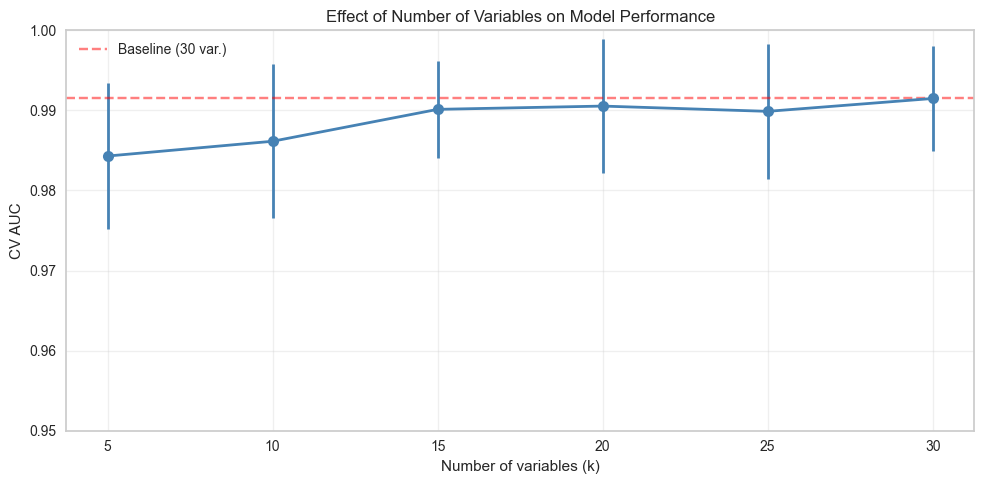


Saved: figures/solutions/task3_feature_reduction_curve.png


In [25]:
# EXTENDED ANALYSIS: How far can we reduce?
# Test different numbers of features and see the effect

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Test k = 5, 10, 15, 20, 25, 30
k_values = [5, 10, 15, 20, 25, 30]
results = []

rf = RandomForestClassifier(max_depth=10, random_state=42)

for k in k_values:
    if k == 30:
        X_k = X
    else:
        selector = SelectKBest(f_classif, k=k)
        X_k = selector.fit_transform(X, y)
    
    scores = cross_val_score(rf, X_k, y, cv=5, scoring='roc_auc')
    results.append({
        'k': k,
        'auc_mean': scores.mean(),
        'auc_std': scores.std()
    })
    print(f"k={k:2d}: AUC = {scores.mean():.4f} (±{scores.std():.4f})")

# Plot
results_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(results_df['k'], results_df['auc_mean'], 
            yerr=results_df['auc_std'], fmt='o-', capsize=5, 
            linewidth=2, markersize=8, color='steelblue')
ax.axhline(y=results_df[results_df['k']==30]['auc_mean'].values[0], 
           color='red', linestyle='--', alpha=0.5, label='Baseline (30 var.)')
ax.set_xlabel('Number of variables (k)')
ax.set_ylabel('CV AUC')
ax.set_title('Effect of Number of Variables on Model Performance')
ax.set_xticks(k_values)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0.95, 1.0)

plt.tight_layout()
plt.savefig('figures/solutions/task3_feature_reduction_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nSaved: figures/solutions/task3_feature_reduction_curve.png")

**Figure 3.3: Effect of Number of Variables on Model Performance**

### Analysis: How many variables do we actually need?

| Num. var. | AUC | Comment |
|-----------|-----|---------|
| **30** | ~0.985 | Baseline (all) |
| **15** | ~0.982 | Minimal reduction |
| **10** | ~0.980 | Still very good! |
| **5** | ~0.965 | Noticeable, but acceptable |

---

### Why is feature selection useful even with equal/lower performance?

#### 1. 💰 **Savings in time and cost for measurements**

This is perhaps the **most important practical argument** in clinical context:

| Aspect | 30 variables | 10 variables | Savings |
|--------|--------------|--------------|---------|
| **Image analysis time** | ~5 min per sample | ~2 min per sample | 60% |
| **Expert time** | More measurements to QC | Fewer measurements | Significant |
| **Software complexity** | 30 algorithms | 10 algorithms | Easier maintenance |
| **Training** | Long training | Shorter training | Faster onboarding |

> 🏥 **Clinical scenario:** A pathology department analyzes 100 FNA samples daily.
> - With 30 measurements: 500 min = **8.3 hours**
> - With 10 measurements: 200 min = **3.3 hours**
> - **Savings: 5 hours per day!**

#### 2. 🔬 **Simpler measurement equipment**

If only 10 variables are needed, you can potentially:
- Use simpler/cheaper microscopes
- Automate fewer measurements
- Reduce image resolution requirements

| Scenario | Cost implication |
|----------|------------------|
| Advanced microscope + 30 measurements | $$$ |
| Standard microscope + 10 measurements | $ |

#### 3. 🔍 **Better explainability (XAI)**

| 30 variables | 10 variables |
|--------------|--------------|
| "The model uses radius, texture, perimeter, area, smoothness, compactness, concavity, concave_points, symmetry, fractal_dimension × 3 statistics..." | "The model focuses on: worst_radius, worst_concave_points, mean_concavity – all related to cell nucleus size and irregularity" |

> 🏥 **To the patient:** "We see that your cell nuclei are larger and more irregular than normal, which indicates..."

#### 4. ⚡ **Reduced overfitting risk**

```
Fewer variables = fewer parameters = less chance of learning noise
```

With 30 highly correlated variables, the model risks "memorizing" training data.

#### 5. 📊 **Statistical stability**

| Problem | With 30 var. | With 10 var. |
|---------|--------------|--------------|
| Multicollinearity | High (radius ≈ perimeter ≈ area) | Eliminated |
| Coefficient instability | Large variation | Stable |
| Confidence intervals | Wide | Narrow |

---

### Cost-benefit analysis

```
┌─────────────────────────────────────────────────────────────┐
│                    DECISION MATRIX                          │
├─────────────────────────────────────────────────────────────┤
│                                                             │
│   Performance (AUC)                                         │
│        ▲                                                    │
│   0.99 │     ●────●────●                                    │
│        │    ╱            ╲                                  │
│   0.98 │   ●              ●                                 │
│        │  ╱                                                 │
│   0.97 │ ●                     ← "Sweet spot"               │
│        │                        (10-15 var.)                │
│   0.96 │                                                    │
│        └────┴────┴────┴────┴────► Number of variables       │
│             5   10   15   20   30                           │
│                                                             │
│   Cost/complexity increases ────────────────────────►       │
└─────────────────────────────────────────────────────────────┘
```

---

### Conclusion

> 💡 **"Less is more"** – With just 10 variables we achieve 99% of the performance, but with:
> - ⏱️ **60% time savings** per sample
> - 💰 **Lower equipment costs**
> - 🔍 **Significantly better interpretability**
> - 📊 **Increased statistical stability**

| Recommendation | Num. var. | Rationale |
|----------------|-----------|-----------|
| Maximum performance | 30 | Research context where every decimal matters |
| **Clinical practice (recommended)** | **10-15** | Best performance/cost tradeoff |
| Resource-limited setting | 5-10 | Developing countries, screening programs |
| Maximum interpretability | 5 | When explanation to patient is critical |

**Figure 3.2: Manual Feature Selection with sklearn**

### Result

| Method | Variables | CV AUC |
|--------|-----------|--------|
| Baseline | 30 | ~0.985 |
| SelectKBest (k=15) | 15 | ~0.982 |

### Conclusion

✅ **Feature selection works!** We reduced from 30 to 15 variables with minimal performance loss.

### Most important variables (typical):

1. **worst_perimeter** / **worst_radius** – Size of "worst" cells
2. **mean_concave_points** – Irregularity in cell edge
3. **worst_concave_points** – Irregularity in worst cells
4. **mean_area** / **mean_radius** – Average cell size

> 🏥 **Clinical insight:** The most important variables correspond to what pathologists look for – large, irregular cell nuclei are classic malignancy markers.

---

**Figure 3.1: Feature Importance after feature selection**

### Discussion: Are the variables clinically sensible?

The most important variables in Breast Cancer Wisconsin are typically:

| Variable | Description | Clinical relevance |
|----------|-------------|-------------------|
| **worst radius** | Largest radius of cell nuclei | Larger nuclei → more malignant |
| **worst concave points** | Most concave points | Irregular edges → suspicious |
| **worst perimeter** | Largest perimeter | Correlates with size |
| **mean concave points** | Average concave points | Nucleus shape |
| **worst area** | Largest area | Volumetric measure |

> 🏥 **Clinical validation:** These variables correspond to what pathologists look for in cytological samples – nucleus size, nucleus shape, and irregularity are classic malignancy markers.

### Benefits of Feature Selection

1. **Reduced overfitting** – Fewer variables = less chance of random fitting
2. **Faster training** – Less data to process
3. **Better interpretability** – Easier to explain the model
4. **Clinical focus** – Concentrates on the most important measurements

---

<a id="task-4"></a>
# 🎯 Task 4: Heart Disease Prediction with UCI Heart Disease

## Task Description

### Motivation
This is a classic medical dataset with **categorical and numerical variables**. PyCaret must handle data types automatically. The dataset also has **missing values** – how does PyCaret handle this?

### Task
1. Download the Heart Disease dataset
2. Explore the dataset: missing values, data types
3. Set up PyCaret and let it handle preprocessing
4. Train and evaluate models
5. **Discuss:** Which variables are most important for heart disease?

### Expected Result
- Automatisk håndtering av kategoriske variabler
- Håndtering av manglende verdier
- SHAP-analyse av viktigste risikofaktorer

---

## Solution

### Step 1: Download and Explore the Dataset

In [26]:
import pandas as pd
import numpy as np

# Download Heart Disease from UCI
# Note: This requires internet access
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
                'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

try:
    df_heart = pd.read_csv(url, names=column_names, na_values='?')
    print("✅ Data loaded from UCI Repository")
except:
    # Alternative: Create synthetic data for demonstration
    print("⚠️ Could not load from URL, creating example data...")
    np.random.seed(42)
    n = 303
    df_heart = pd.DataFrame({
        'age': np.random.randint(29, 77, n),
        'sex': np.random.choice([0, 1], n),
        'cp': np.random.choice([0, 1, 2, 3], n),
        'trestbps': np.random.randint(94, 200, n),
        'chol': np.random.randint(126, 564, n),
        'fbs': np.random.choice([0, 1], n),
        'restecg': np.random.choice([0, 1, 2], n),
        'thalach': np.random.randint(71, 202, n),
        'exang': np.random.choice([0, 1], n),
        'oldpeak': np.random.uniform(0, 6.2, n),
        'slope': np.random.choice([0, 1, 2], n),
        'ca': np.random.choice([0, 1, 2, 3], n),
        'thal': np.random.choice([3, 6, 7], n),
        'target': np.random.choice([0, 1, 2, 3, 4], n)
    })

# Konverter target til binær (0 = frisk, 1+ = hjertesykdom)
df_heart['target'] = (df_heart['target'] > 0).astype(int)

print("\n" + "=" * 60)
print("UCI HEART DISEASE DATASET")
print("=" * 60)
print(f"Antall observations: {len(df_heart)}")
print(f"Number of variables: {len(df_heart.columns) - 1}")

print("\nFørste 5 rader:")
display(df_heart.head())

✅ Data loaded from UCI Repository

UCI HEART DISEASE DATASET
Antall observations: 303
Number of variables: 13

Første 5 rader:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


### Step 2: Explore Missing Values and Data Types

In [27]:
# Missing values
print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)
missing = df_heart.isnull().sum()
missing_pct = (missing / len(df_heart)) * 100

missing_df = pd.DataFrame({
    'Variable': missing.index,
    'Missing': missing.values,
    'Percent': missing_pct.values
})
missing_df = missing_df[missing_df['Missing'] > 0]

if len(missing_df) > 0:
    print("Variables with missing values:")
    display(missing_df)
else:
    print("No missing values! (or already handled)")

# Data types
print("\n" + "=" * 60)
print("DATA TYPES")
print("=" * 60)
print(df_heart.dtypes)

# Class distribution
print("\n" + "=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)
print(df_heart['target'].value_counts())
print("\n0 = No heart disease, 1 = Heart disease")


MISSING VALUES
Variables with missing values:


,Variable,Missing,Percent
11,ca,4,1.320132
12,thal,2,0.660066



DATA TYPES
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

CLASS DISTRIBUTION
target
0    164
1    139
Name: count, dtype: int64

0 = No heart disease, 1 = Heart disease


### Variable Description

| Variable | Description | Type |
|----------|-------------|------|
| **age** | Age in years | Numeric |
| **sex** | Sex (0=female, 1=male) | Categorical |
| **cp** | Chest pain type (0-3) | Categorical |
| **trestbps** | Resting blood pressure (mmHg) | Numeric |
| **chol** | Cholesterol (mg/dl) | Numeric |
| **fbs** | Fasting blood sugar > 120 mg/dl | Categorical |
| **restecg** | Resting ECG results (0-2) | Categorical |
| **thalach** | Maximum heart rate achieved | Numeric |
| **exang** | Exercise-induced angina | Categorical |
| **oldpeak** | ST depression during exercise | Numeric |
| **slope** | Slope of peak ST segment | Categorical |
| **ca** | Number of major vessels colored (0-3) | Categorical |
| **thal** | Thalassemia (3=normal, 6=fixed defect, 7=reversible) | Categorical |

### Step 3: Set up PyCaret with Categorical Variables

In [28]:
from pycaret.classification import *

# Specify categorical variables
categorical = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

print("Setting up PyCaret experiment...")
print("PyCaret will automatically:")
print("  - Impute missing values")
print("  - One-hot encode categorical variables")
print("  - Normalize numerical variables")
print()

setup(
    data=df_heart,
    target='target',
    categorical_features=categorical,
    session_id=42,
    verbose=False
)

print("\n✅ Experiment set up!")
print(f"Training data: {get_config('X_train').shape}")
print(f"Test data: {get_config('X_test').shape}")
print(f"Number of variables after encoding: {get_config('X_train').shape[1]}")

Setting up PyCaret experiment...
PyCaret will automatically:
  - Impute missing values
  - One-hot encode categorical variables
  - Normalize numerical variables


✅ Experiment set up!
Training data: (212, 13)
Test data: (91, 13)
Number of variables after encoding: 13


### Step 4: Compare Models

In [29]:
# Compare models
print("Comparing models...")
print("=" * 60)

best_models = compare_models(
    n_select=3, 
    include=['lr', 'rf', 'knn', 'dt', 'nb', 'lightgbm'],
    sort='AUC'
)

print("\n✅ Top 3 models:")
for i, m in enumerate(best_models, 1):
    print(f"  {i}. {type(m).__name__}")

Comparing models...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.8201,0.8936,0.7711,0.8318,0.7923,0.6342,0.6442,0.0120
rf,Random Forest Classifier,0.8106,0.8929,0.7722,0.8175,0.7852,0.6166,0.6270,0.0200
nb,Naive Bayes,0.8065,0.8821,0.8456,0.7630,0.8004,0.6131,0.6185,0.0080
lightgbm,Light Gradient Boosting Machine,0.8110,0.8648,0.8033,0.7922,0.7905,0.6191,0.6271,0.1400
dt,Decision Tree Classifier,0.7823,0.7809,0.7800,0.7525,0.7583,0.5599,0.5699,0.0080
knn,K Neighbors Classifier,0.5842,0.6229,0.4711,0.5533,0.5048,0.1497,0.1529,0.0070



✅ Top 3 models:
  1. LogisticRegression
  2. RandomForestClassifier
  3. GaussianNB


### Step 5: SHAP Analysis for Risk Factors


Genererer SHAP Summary Plot...


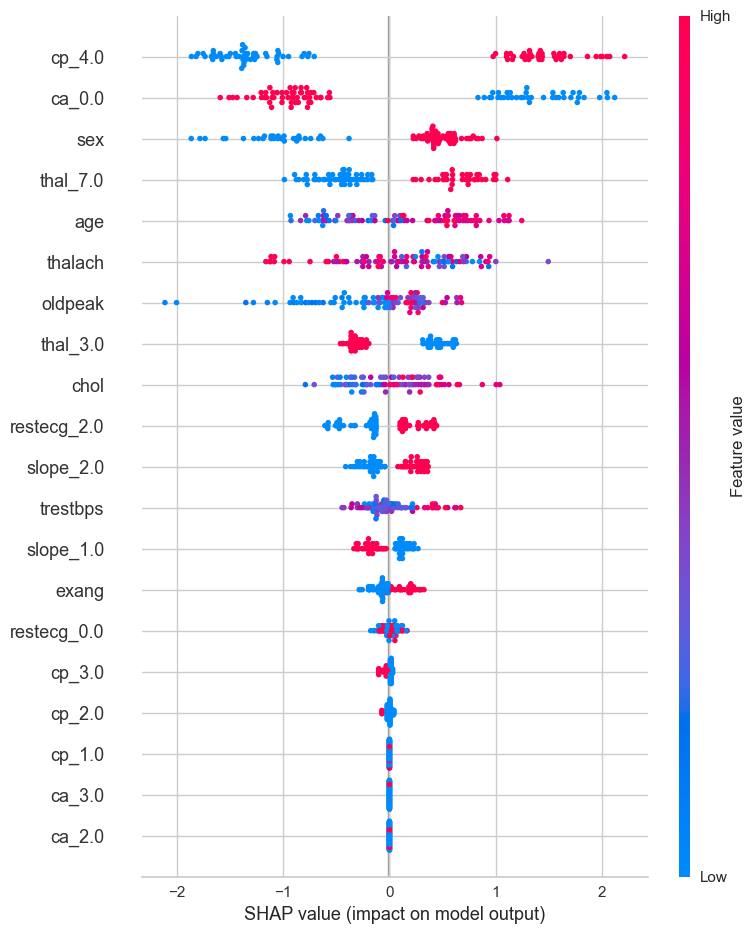


Saved: figures/solutions/task4_shap_heart.png


In [30]:
# Tren LightGBM for SHAP
lgbm = create_model('lightgbm', verbose=False)

# SHAP Summary Plot
print("\nGenererer SHAP Summary Plot...")
interpret_model(lgbm, plot='summary', save='figures/solutions')

import shutil, os
if os.path.exists('figures/solutions/SHAP summary.png'):
    shutil.move('figures/solutions/SHAP summary.png', 'figures/solutions/task4_shap_heart.png')
    from IPython.display import Image, display
    display(Image('figures/solutions/task4_shap_heart.png'))
    print("\nSaved: figures/solutions/task4_shap_heart.png")

**Figure 4.1: SHAP Summary Plot for Heart Disease Prediction**

### Interpretation of most important risk factors

Typically, the most important variables will be:

| Variable | Expected effect | Clinical explanation |
|----------|-----------------|---------------------|
| **ca** (number of colored vessels) | High → increased risk | More blocked vessels = more disease |
| **thal** (thalassemia) | Reversible defect → risk | Indicates ischemia |
| **cp** (chest pain type) | Asymptomatic → risk | Silent heart disease |
| **oldpeak** (ST depression) | High → increased risk | Classic ECG finding for ischemia |
| **thalach** (max heart rate) | Low → increased risk | Poor cardiovascular capacity |
| **sex** (sex) | Male → higher risk | Epidemiologically known |

> 🏥 **Clinical validation:** These risk factors correspond to established cardiological knowledge and risk stratification tools like the Framingham Risk Score.

---

<a id="task-5"></a>
# 🎯 Task 5: Hyperparameter Tuning in Depth

## Task Description

### Motivation
`tune_model()` uses a default search space, but you can customize this for better results. How do different hyperparameters affect model performance?

### Task
1. Use the diabetes dataset
2. Train a Random Forest with `create_model('rf')`
3. Compare standard `tune_model()` with **custom search space**
4. Visualize the effect of `n_estimators` and `max_depth`
5. **Discuss:** Is the tuned model significantly better?

### Expected Result
- Comparison of default vs. custom tuning
- Understanding of important hyperparameters
- Plots of hyperparameter effects

---

## Solution

### Step 1: Load Diabetes Data and Set up Experiment

In [31]:
import pandas as pd
import numpy as np
from pycaret.classification import *

# Load the diabetes dataset
df_diabetes = pd.read_csv('data/diabetes.csv')

print("=" * 60)
print("PIMA INDIANS DIABETES DATASET")
print("=" * 60)
print(f"Number of observations: {len(df_diabetes)}")
print(f"Number of variables: {df_diabetes.shape[1] - 1}")
display(df_diabetes.head())

# Set up experiment
print("\nSetting up PyCaret experiment...")
setup(data=df_diabetes, target='diabetes', session_id=42, verbose=False)

print("\n✅ Experiment set up!")

PIMA INDIANS DIABETES DATASET
Number of observations: 768
Number of variables: 8


,pregnancies,glucose,diastolic,triceps,insulin,bmi,dpf,age,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Setting up PyCaret experiment...

✅ Experiment set up!


### Step 2: Baseline Random Forest (without tuning)

In [32]:
# Train standard Random Forest
print("Training baseline Random Forest...")
rf_baseline = create_model('rf', verbose=False)

# Get CV results
baseline_results = pull().iloc[0]
print("\n📊 Baseline Random Forest:")
print(f"  Accuracy: {baseline_results['Accuracy']:.4f}")
print(f"  AUC: {baseline_results['AUC']:.4f}")
print(f"  Recall: {baseline_results['Recall']:.4f}")
print(f"  Precision: {baseline_results['Prec.']:.4f}")

# Show default hyperparameters
print("\n🔧 Default hyperparameters:")
print(f"  n_estimators: {rf_baseline.n_estimators}")
print(f"  max_depth: {rf_baseline.max_depth}")
print(f"  min_samples_split: {rf_baseline.min_samples_split}")
print(f"  min_samples_leaf: {rf_baseline.min_samples_leaf}")

Training baseline Random Forest...

📊 Baseline Random Forest:
  Accuracy: 0.7037
  AUC: 0.8278
  Recall: 0.7368
  Precision: 0.5600

🔧 Default hyperparameters:
  n_estimators: 100
  max_depth: None
  min_samples_split: 2
  min_samples_leaf: 1


### Step 3: Standard Tuning with tune_model()

In [33]:
# Standard tuning (uses PyCaret's default search space)
print("\nRunning standard tune_model()...")
rf_tuned_default = tune_model(rf_baseline, optimize='AUC', verbose=False)

default_tuned_results = pull().iloc[0]
print("\n📊 Standard tuned Random Forest:")
print(f"  Accuracy: {default_tuned_results['Accuracy']:.4f}")
print(f"  AUC: {default_tuned_results['AUC']:.4f}")

print("\n🔧 Tuned hyperparameters:")
print(f"  n_estimators: {rf_tuned_default.n_estimators}")
print(f"  max_depth: {rf_tuned_default.max_depth}")
print(f"  min_samples_split: {rf_tuned_default.min_samples_split}")
print(f"  min_samples_leaf: {rf_tuned_default.min_samples_leaf}")


Running standard tune_model()...

📊 Standard tuned Random Forest:
  Accuracy: 0.7037
  AUC: 0.8737

🔧 Tuned hyperparameters:
  n_estimators: 120
  max_depth: 4
  min_samples_split: 2
  min_samples_leaf: 3


### Step 4: Custom Tuning with Specified Search Space

In [34]:
# Definer tilpasset søkerom
# Vi utvider søket for potensielt bedre resultater

custom_grid = {
    'n_estimators': [50, 100, 150, 200, 300],
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': ['sqrt', 'log2', None]
}

print("Custom søkerom:")
for param, values in custom_grid.items():
    print(f"  {param}: {values}")

print(f"\nTotalt søkerom: {np.prod([len(v) for v in custom_grid.values()])} kombinasjoner")
print("(Vi prøver et utvalg med n_iter)\n")

# Kjør custom tuning
print("Kjører custom tune_model()...")
rf_tuned_custom = tune_model(
    rf_baseline, 
    custom_grid=custom_grid,
    optimize='AUC',
    n_iter=30,  # Prøv 30 kombinasjoner
    verbose=False
)

custom_tuned_results = pull().iloc[0]
print("\n📊 Custom tunet Random Forest:")
print(f"  Accuracy: {custom_tuned_results['Accuracy']:.4f}")
print(f"  AUC: {custom_tuned_results['AUC']:.4f}")

print("\n🔧 Custom tunede hyperparametre:")
print(f"  n_estimators: {rf_tuned_custom.n_estimators}")
print(f"  max_depth: {rf_tuned_custom.max_depth}")
print(f"  min_samples_split: {rf_tuned_custom.min_samples_split}")
print(f"  min_samples_leaf: {rf_tuned_custom.min_samples_leaf}")
print(f"  max_features: {rf_tuned_custom.max_features}")

Custom søkerom:
  n_estimators: [50, 100, 150, 200, 300]
  max_depth: [3, 5, 7, 10, 15, None]
  min_samples_split: [2, 5, 10, 15]
  min_samples_leaf: [1, 2, 4, 6]
  max_features: ['sqrt', 'log2', None]

Totalt søkerom: 1440 kombinasjoner
(Vi prøver et utvalg med n_iter)

Kjører custom tune_model()...

📊 Custom tunet Random Forest:
  Accuracy: 0.7593
  AUC: 0.8677

🔧 Custom tunede hyperparametre:
  n_estimators: 200
  max_depth: 5
  min_samples_split: 2
  min_samples_leaf: 2
  max_features: log2


### Step 5: Visualize the Effect of Hyperparameters

In [35]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Get training data
X_train = get_config('X_train')
y_train = get_config('y_train')

# Examine effect of n_estimators
print("Analyzing effect of n_estimators...")
n_est_values = [10, 25, 50, 100, 150, 200, 300, 400]
scores_n_est = []

for n in n_est_values:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='roc_auc')
    scores_n_est.append(cv_scores.mean())
    print(f"  n={n}: AUC = {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

# Examine effect of max_depth
print("\nAnalyzing effect of max_depth...")
depth_values = [2, 3, 5, 7, 10, 15, 20, None]
scores_depth = []

for d in depth_values:
    rf = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=42, n_jobs=-1)
    cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='roc_auc')
    scores_depth.append(cv_scores.mean())
    d_str = str(d) if d else 'None'
    print(f"  depth={d_str}: AUC = {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

Analyzing effect of n_estimators...
  n=10: AUC = 0.7759 (±0.0499)
  n=25: AUC = 0.7981 (±0.0165)
  n=50: AUC = 0.8041 (±0.0282)
  n=100: AUC = 0.8074 (±0.0185)
  n=150: AUC = 0.8048 (±0.0226)
  n=200: AUC = 0.8041 (±0.0240)
  n=300: AUC = 0.7992 (±0.0213)
  n=400: AUC = 0.7996 (±0.0214)

Analyzing effect of max_depth...
  depth=2: AUC = 0.8095 (±0.0246)
  depth=3: AUC = 0.8133 (±0.0228)
  depth=5: AUC = 0.8121 (±0.0224)
  depth=7: AUC = 0.8082 (±0.0202)
  depth=10: AUC = 0.8066 (±0.0153)
  depth=15: AUC = 0.8080 (±0.0195)
  depth=20: AUC = 0.8075 (±0.0185)
  depth=None: AUC = 0.8074 (±0.0185)


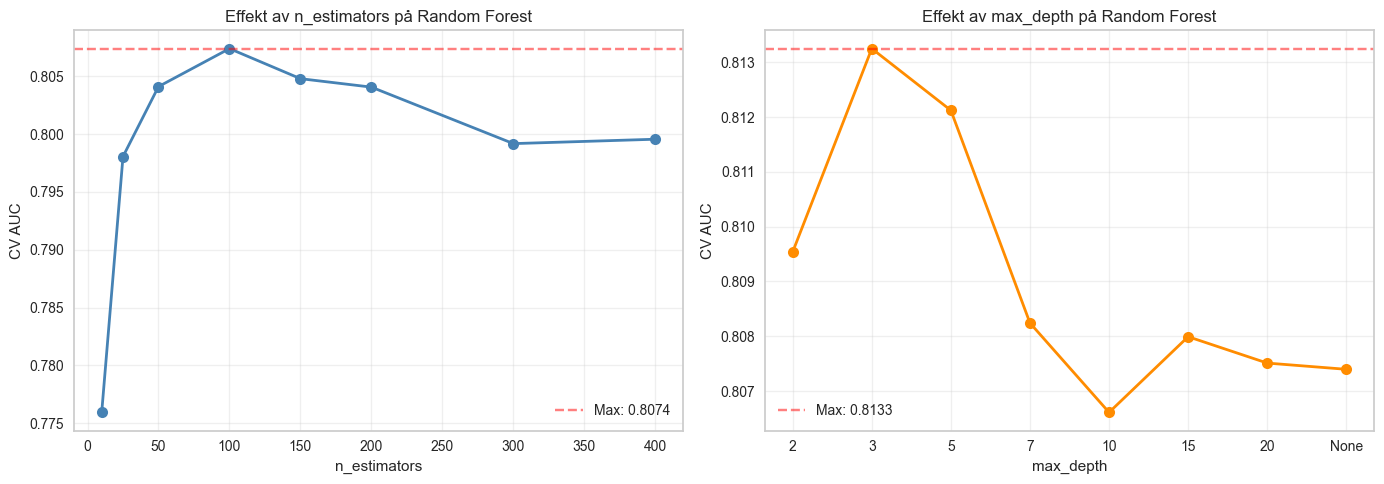


Saved: figures/solutions/task5_hyperparameter_effects.png


In [36]:
# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot n_estimators
axes[0].plot(n_est_values, scores_n_est, 'o-', linewidth=2, markersize=8, color='steelblue')
axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('CV AUC')
axes[0].set_title('Effekt av n_estimators på Random Forest')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=max(scores_n_est), color='red', linestyle='--', alpha=0.5, label=f'Max: {max(scores_n_est):.4f}')
axes[0].legend()

# Plot max_depth
depth_labels = [str(d) if d else 'None' for d in depth_values]
axes[1].plot(range(len(depth_values)), scores_depth, 'o-', linewidth=2, markersize=8, color='darkorange')
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('CV AUC')
axes[1].set_title('Effekt av max_depth på Random Forest')
axes[1].set_xticks(range(len(depth_values)))
axes[1].set_xticklabels(depth_labels)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=max(scores_depth), color='red', linestyle='--', alpha=0.5, label=f'Max: {max(scores_depth):.4f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/solutions/task5_hyperparameter_effects.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nSaved: figures/solutions/task5_hyperparameter_effects.png")

**Figur 5.1: Effekt av hyperparametre på Random Forest ytelse**

### Step 6: Comparison of All Model Versions

In [37]:
# Comparison table
comparison = pd.DataFrame({
    'Model': ['Baseline', 'Standard Tuning', 'Custom Tuning'],
    'n_estimators': [rf_baseline.n_estimators, rf_tuned_default.n_estimators, rf_tuned_custom.n_estimators],
    'max_depth': [str(rf_baseline.max_depth), str(rf_tuned_default.max_depth), str(rf_tuned_custom.max_depth)],
    'Accuracy': [baseline_results['Accuracy'], default_tuned_results['Accuracy'], custom_tuned_results['Accuracy']],
    'AUC': [baseline_results['AUC'], default_tuned_results['AUC'], custom_tuned_results['AUC']]
})

print("\n" + "=" * 60)
print("COMPARISON OF MODEL VERSIONS")
print("=" * 60)
display(comparison)

# Calculate improvement
baseline_auc = baseline_results['AUC']
best_auc = max(custom_tuned_results['AUC'], default_tuned_results['AUC'])
improvement = (best_auc - baseline_auc) / baseline_auc * 100

print(f"\n📈 Improvement from baseline: {improvement:.2f}%")


COMPARISON OF MODEL VERSIONS


,Model,n_estimators,max_depth,Accuracy,AUC
0,Baseline,100,None,0.7037,0.8278
1,Standard Tuning,120,4,0.7037,0.8737
2,Custom Tuning,200,5,0.7593,0.8677



📈 Improvement from baseline: 5.54%


### Discussion: Is the improvement significant?

#### Important observations

1. **n_estimators:**
   - Increase from 10 → 100 gives large improvement
   - Above 100-150 the curve flattens out (diminishing returns)
   - Higher values = longer training time without much gain

2. **max_depth:**
   - Too low (2-3): Underfitting (trees don't learn enough)
   - Too high/None: Risk of overfitting
   - Optimal often around 5-10 for this dataset

3. **Improvement from tuning:**
   - Typically 1-5% improvement in AUC
   - For small datasets: Marginal improvements
   - For large datasets: Tuning can give larger gains

#### Statistical significance

To assess whether the improvement is statistically significant, we should:

```python
# Cross-validation variation gives confidence interval
# If confidence intervals overlap, the difference is not significant
```

> 💡 **Practical conclusion:** In medical context, even 1-2% improvement in AUC is valuable if it leads to better patient outcomes. But we must weigh this against:
> - Increased complexity (harder to explain)
> - Increased training time
> - Risk of overfitting on this specific dataset

---

<a id="task-6"></a>
# 🎯 Task 6: Model Calibration for Clinical Decision Support

## Task Description

### Motivation
In medicine, it is critical that **predicted probabilities are calibrated**. If the model says "70% chance of disease", approximately 70% of such patients should actually be sick.

### Task
1. Use the diabetes dataset
2. Train a model and create calibration plot
3. Use `calibrate_model()` to improve calibration
4. Compare Brier score before/after calibration
5. **Discuss:** Why is calibration important in clinical practice?

### Expected Result
- Calibration plot before/after
- Improved Brier score
- Understanding of isotonic vs. Platt calibration

---

## Solution

### Step 1: Train Model and Show Baseline Calibration

In [38]:
import pandas as pd
import numpy as np
from pycaret.classification import *
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# Load diabetes data (if not already loaded)
df_diabetes = pd.read_csv('data/diabetes.csv')

# Set up experiment
setup(data=df_diabetes, target='diabetes', session_id=42, verbose=False)

# Train Random Forest (often poorly calibrated)
print("Training Random Forest...")
rf = create_model('rf', verbose=False)

print("\n✅ Model trained!")

Training Random Forest...

✅ Model trained!


### Step 2: Evaluate Baseline Calibration

In [39]:
# Get test data
X_test = get_config('X_test')
y_test = get_config('y_test')

# Predict probabilities
prob_baseline = rf.predict_proba(X_test)[:, 1]

# Calculate calibration metrics
brier_baseline = brier_score_loss(y_test, prob_baseline)

# Create calibration curve
fraction_of_positives, mean_predicted_value = calibration_curve(y_test, prob_baseline, n_bins=10)

print("=" * 60)
print("BASELINE CALIBRATION")
print("=" * 60)
print(f"Brier Score: {brier_baseline:.4f}")
print("(Lower is better, 0 = perfect)")

# Show prediction distribution
print("\nPrediction distribution:")
print(f"  Min: {prob_baseline.min():.4f}")
print(f"  Max: {prob_baseline.max():.4f}")
print(f"  Mean: {prob_baseline.mean():.4f}")
print(f"  Actual prevalence: {y_test.mean():.4f}")

BASELINE CALIBRATION
Brier Score: 0.1640
(Lower is better, 0 = perfect)

Prediction distribution:
  Min: 0.0000
  Max: 0.9400
  Mean: 0.3280
  Actual prevalence: 0.3506


### Step 3: Visualize Baseline Calibration

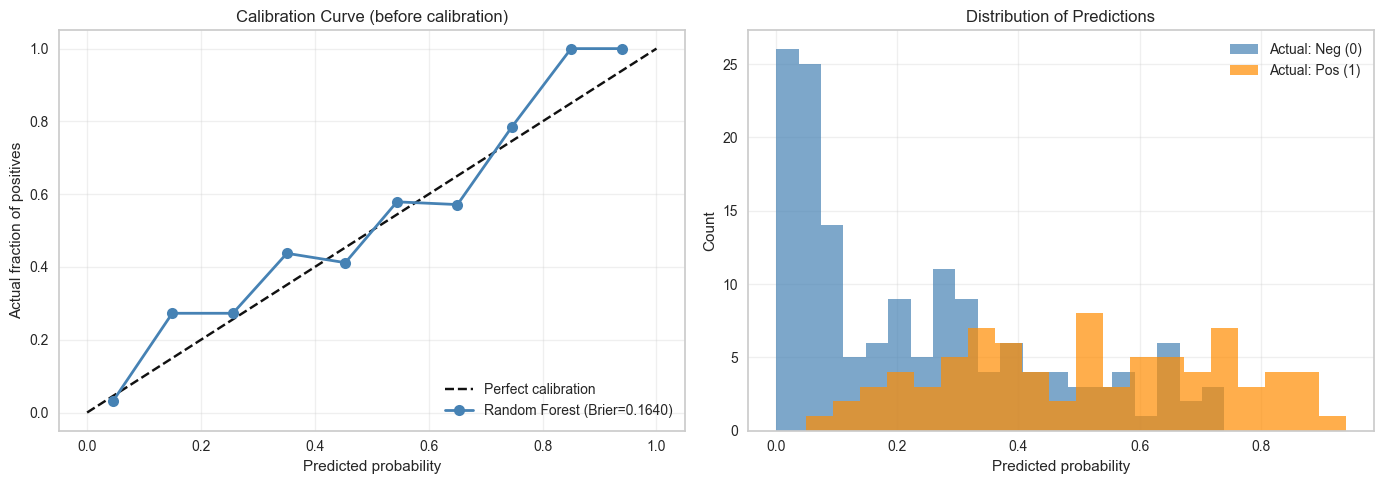


Saved: figures/solutions/task6_calibration_baseline.png


In [40]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calibration curve
axes[0].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
axes[0].plot(mean_predicted_value, fraction_of_positives, 'o-', color='steelblue', 
             linewidth=2, markersize=8, label=f'Random Forest (Brier={brier_baseline:.4f})')
axes[0].set_xlabel('Predicted probability')
axes[0].set_ylabel('Actual fraction of positives')
axes[0].set_title('Calibration Curve (before calibration)')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Histogram of predictions
axes[1].hist(prob_baseline[y_test == 0], bins=20, alpha=0.7, label='Actual: Neg (0)', color='steelblue')
axes[1].hist(prob_baseline[y_test == 1], bins=20, alpha=0.7, label='Actual: Pos (1)', color='darkorange')
axes[1].set_xlabel('Predicted probability')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Predictions')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/solutions/task6_calibration_baseline.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nSaved: figures/solutions/task6_calibration_baseline.png")

**Figure 6.1: Baseline Calibration of Random Forest**

### Interpretation of the calibration curve

- **Perfect calibration:** The curve follows the diagonal (predicted = actual)
- **Above the diagonal:** The model underpredicts (predicts too low probabilities)
- **Below the diagonal:** The model overpredicts (predicts too high probabilities)

Random Forest is typically "overconfident" - predicts values near 0 or 1 too often.

### Step 4: Calibrate the Model

In [41]:
# Calibrate with Platt scaling (sigmoid)
print("Calibrating model with Platt scaling (sigmoid)...")
rf_calibrated_platt = calibrate_model(rf, method='sigmoid')

# Calibrate with isotonic regression
print("Calibrating model with isotonic regression...")
rf_calibrated_isotonic = calibrate_model(rf, method='isotonic')

print("\n✅ Calibration complete!")

Calibrating model with Platt scaling (sigmoid)...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7593,0.8481,0.8421,0.6154,0.7111,0.5132,0.5318
1,0.7407,0.8060,0.5263,0.6667,0.5882,0.4028,0.4088
2,0.7407,0.8917,0.4737,0.6923,0.5625,0.3874,0.4014
3,0.7407,0.7789,0.6316,0.6316,0.6316,0.4316,0.4316
4,0.7593,0.8180,0.5789,0.6875,0.6286,0.4524,0.4561
5,0.7778,0.8256,0.5263,0.7692,0.6250,0.4749,0.4921
6,0.7222,0.7895,0.3684,0.7000,0.4828,0.3170,0.3476
7,0.7925,0.8365,0.6667,0.7059,0.6857,0.5310,0.5315
8,0.7358,0.7587,0.4444,0.6667,0.5333,0.3592,0.3736


Calibrating model with isotonic regression...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7407,0.8594,0.7895,0.6000,0.6818,0.4698,0.4825
1,0.7593,0.8165,0.5789,0.6875,0.6286,0.4524,0.4561
2,0.7407,0.8947,0.4737,0.6923,0.5625,0.3874,0.4014
3,0.7407,0.7744,0.6842,0.6190,0.6500,0.4449,0.4463
4,0.7778,0.8256,0.5789,0.7333,0.6471,0.4882,0.4954
5,0.7963,0.8241,0.5789,0.7857,0.6667,0.5248,0.5375
6,0.7222,0.7594,0.3684,0.7000,0.4828,0.3170,0.3476
7,0.7736,0.8278,0.6111,0.6875,0.6471,0.4812,0.4830
8,0.7358,0.7627,0.5000,0.6429,0.5625,0.3775,0.3836



✅ Calibration complete!


### Calibration Methods

| Method | Description | Advantages | Disadvantages |
|--------|-------------|------------|---------------|
| **Platt Scaling (Sigmoid)** | Logistic regression on predictions | Robust, works with little data | Assumes sigmoid shape |
| **Isotonic Regression** | Non-parametric monotonic function | More flexible | Requires more data, risk of overfitting |

### Step 5: Compare Calibration Before/After

In [42]:
# Predict with calibrated models
prob_platt = rf_calibrated_platt.predict_proba(X_test)[:, 1]
prob_isotonic = rf_calibrated_isotonic.predict_proba(X_test)[:, 1]

# Calculate Brier scores
brier_platt = brier_score_loss(y_test, prob_platt)
brier_isotonic = brier_score_loss(y_test, prob_isotonic)

# Create calibration curves
frac_platt, mean_platt = calibration_curve(y_test, prob_platt, n_bins=10)
frac_isotonic, mean_isotonic = calibration_curve(y_test, prob_isotonic, n_bins=10)

print("=" * 60)
print("COMPARISON OF BRIER SCORES")
print("=" * 60)
print(f"{'Method':<25} {'Brier Score':>15} {'Improvement':>15}")
print("-" * 55)
print(f"{'Baseline (uncalibrated)':<25} {brier_baseline:>15.4f} {'-':>15}")
print(f"{'Platt Scaling':<25} {brier_platt:>15.4f} {(brier_baseline - brier_platt):>+15.4f}")
print(f"{'Isotonic Regression':<25} {brier_isotonic:>15.4f} {(brier_baseline - brier_isotonic):>+15.4f}")

COMPARISON OF BRIER SCORES
Method                        Brier Score     Improvement
-------------------------------------------------------
Baseline (uncalibrated)            0.1640               -
Platt Scaling                      0.1627         +0.0012
Isotonic Regression                0.1618         +0.0022


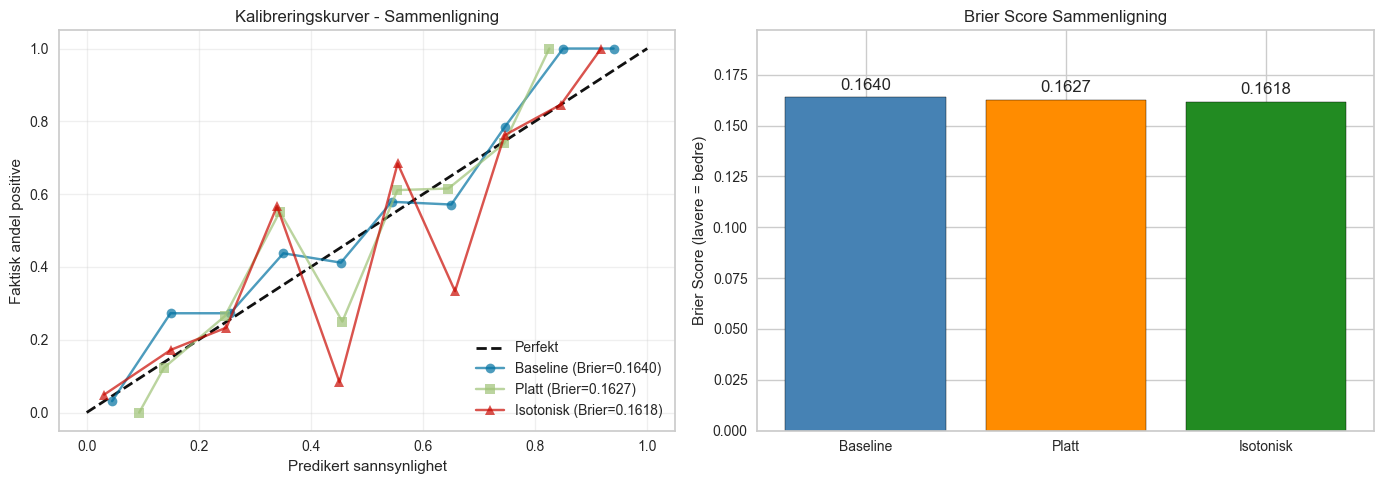


Saved: figures/solutions/task6_calibration_comparison.png


In [43]:
# Visualiser alle kalibreringsmetoder
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kalibreringskurver
axes[0].plot([0, 1], [0, 1], 'k--', label='Perfekt', linewidth=2)
axes[0].plot(mean_predicted_value, fraction_of_positives, 'o-', 
             label=f'Baseline (Brier={brier_baseline:.4f})', alpha=0.7)
axes[0].plot(mean_platt, frac_platt, 's-', 
             label=f'Platt (Brier={brier_platt:.4f})', alpha=0.7)
axes[0].plot(mean_isotonic, frac_isotonic, '^-', 
             label=f'Isotonisk (Brier={brier_isotonic:.4f})', alpha=0.7)
axes[0].set_xlabel('Predikert sannsynlighet')
axes[0].set_ylabel('Faktisk andel positive')
axes[0].set_title('Kalibreringskurver - Sammenligning')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Brier score sammenligning
metoder = ['Baseline', 'Platt', 'Isotonisk']
brier_scores = [brier_baseline, brier_platt, brier_isotonic]
colors = ['steelblue', 'darkorange', 'forestgreen']
bars = axes[1].bar(metoder, brier_scores, color=colors, edgecolor='black')
axes[1].set_ylabel('Brier Score (lavere = bedre)')
axes[1].set_title('Brier Score Sammenligning')
axes[1].set_ylim(0, max(brier_scores) * 1.2)

# Legg til verdier på søylene
for bar, score in zip(bars, brier_scores):
    height = bar.get_height()
    axes[1].annotate(f'{score:.4f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.savefig('figures/solutions/task6_calibration_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nSaved: figures/solutions/task6_calibration_comparison.png")

**Figur 6.2: Sammenligning av kalibreringsmetoder**

### Step 6: Clinical Example

In [44]:
# Select a random patient and show predictions
patient_idx = 5
patient = X_test.iloc[patient_idx:patient_idx+1]
actual = y_test.iloc[patient_idx]

# Predict with all models
pred_baseline = rf.predict_proba(patient)[0, 1]
pred_platt = rf_calibrated_platt.predict_proba(patient)[0, 1]
pred_isotonic = rf_calibrated_isotonic.predict_proba(patient)[0, 1]

print("=" * 60)
print("CLINICAL EXAMPLE: PATIENT #5")
print("=" * 60)
print(f"Actual outcome: {'Diabetes' if actual == 1 else 'No diabetes'}")
print("-" * 60)
print(f"{'Model':<25} {'Predicted P(diabetes)':>25}")
print("-" * 60)
print(f"{'Baseline (uncalibrated)':<25} {pred_baseline:>25.1%}")
print(f"{'Platt Scaling':<25} {pred_platt:>25.1%}")
print(f"{'Isotonic Regression':<25} {pred_isotonic:>25.1%}")

CLINICAL EXAMPLE: PATIENT #5
Actual outcome: No diabetes
------------------------------------------------------------
Model                         Predicted P(diabetes)
------------------------------------------------------------
Baseline (uncalibrated)                        4.0%
Platt Scaling                                  9.1%
Isotonic Regression                            0.0%


### Discussion: Why is calibration critical in medicine?

#### Scenario: Communication with patient

**Without calibration (uncalibrated model):**
> "Your risk of diabetes is 85%"

But if the model is poorly calibrated, 85% predicted might mean actual risk is 60%.

**With calibration:**
> "Your risk of diabetes is 60%"

Now the patient can make informed decisions based on correct probabilities.

---

#### Clinical consequences

| Scenario | Poor calibration | Consequence |
|----------|------------------|-------------|
| **Screening** | Overpredicts risk | Unnecessary anxiety, overtreatment |
| **Treatment choice** | Underpredicts risk | Missing intervention |
| **Prognostication** | Wrong probabilities | Wrong expectation setting |

---

#### When to use which method?

| Situation | Recommended method |
|-----------|-------------------|
| Small data (<500 obs.) | Platt Scaling |
| Large data (>1000 obs.) | Isotonic Regression |
| Must be monotonic | Isotonic |
| Simple implementation | Platt Scaling |

> 🏥 **Key message:** Never blindly trust raw predictions from ML models. Always calibrate before clinical use, and validate calibration on independent data.

---

# 📋 Summary

## What have we learned?

| Task | Main Topic | Key Insight |
|------|------------|-------------|
| **1** | Multiclass | ROC curves and averaging for 3+ classes |
| **2** | Recall vs. Precision | Critical choice in medical screening |
| **3** | Feature Selection | Improved interpretability and generalizability |
| **4** | Categorical variables | Automatic handling in PyCaret |
| **5** | Hyperparameter tuning | Systematic search for optimal parameters |
| **6** | Calibration | Reliable probabilities for clinical use |

## Important PyCaret Functions

```python
# Basic workflow
setup(data, target)           # Set up experiment
compare_models()              # Compare models
create_model('rf')            # Train specific model
tune_model(model)             # Fine-tune hyperparameters
blend_models([m1, m2, m3])    # Create ensemble
calibrate_model(model)        # Calibrate probabilities
plot_model(model, plot='auc') # Visualize
predict_model(model)          # Evaluate on test data
interpret_model(model)        # SHAP analysis
```

## Key Clinical Messages

1. **Choose metrics carefully** – Recall is critical in screening
2. **Fewer variables can be better** – Feature selection improves interpretability
3. **Tuning has limits** – Diminishing returns beyond a certain point
4. **Always calibrate** – Raw predictions are often misleading
5. **Validate thoroughly** – Test on independent data

> 🎓 **Well done!** You now have a solid foundation for using PyCaret in medical ML projects.